# Agentes inteligentes


In [ ]:
!pip install agentpy


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import agentpy as ap
import random
from matplotlib.animation import FuncAnimation
import IPython.display as display
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Graficación de las rutas y cruces

In [ ]:

# FUNCIONES AUXILIARES


def bezier_curve(pts, num_points=2000):
    t = np.linspace(0, 1, num_points)[:, None]
    p = np.array(pts, dtype=float)

    if len(p) == 3:
        return (1-t)**2 * p[0] + 2*(1-t)*t * p[1] + t**2 * p[2]

    if len(p) == 4:
        return (
            (1-t)**3 * p[0]
            + 3*(1-t)**2*t * p[1]
            + 3*(1-t)*t**2 * p[2]
            + t**3 * p[3]
        )

    raise ValueError("Bezier solo soporta 3 o 4 puntos")

In [ ]:


def gps_to_local_xy(lat, lon, lat0, lon0):
    """
    GPS -> metros usando aproximación local
    """

    R = 6378137.0

    dlat = np.radians(lat - lat0)
    dlon = np.radians(lon - lon0)

    x = R * dlon * np.cos(np.radians(lat0))
    y = R * dlat

    return np.array([x, y])

In [ ]:

# GPS REALES

GPS_POINTS = {
    "JDLV_FGR": (25.653568, -100.289781),
    "NOGALES_AHUEHUETES": (25.653804, -100.287868),
    "LUIS_ELIZONDO": (25.652986, -100.284128),
    "PRIMAVERA_1": (25.652364, -100.281373),
    "PRIMAVERA_2": (25.652270, -100.280378),
}

# CONVERSIÓN A METROS

lat0, lon0 = GPS_POINTS["JDLV_FGR"]

NODES = {}

for name, (lat, lon) in GPS_POINTS.items():
    NODES[name] = gps_to_local_xy(
        lat,
        lon,
        lat0,
        lon0
    )
ln=1

In [ ]:
def generate_waypoints(points, num_points=900, smooth_factor=12.0):
    pts = np.array(points, dtype=float)
    if len(pts) <= 2:
        t = np.linspace(0, 1, num_points)[:, None]
        return list(zip(*((1 - t) * pts[0] + t * pts[1]).T))

    smoothed = [pts[0]]
    for i in range(1, len(pts) - 1):
        p_prev, p_curr, p_next = pts[i - 1], pts[i], pts[i + 1]
        v1, v2 = p_prev - p_curr, p_next - p_curr
        r1 = min(smooth_factor, np.hypot(*v1) * 0.4)
        r2 = min(smooth_factor, np.hypot(*v2) * 0.4)
        pt1 = p_curr + (v1 / np.hypot(*v1)) * r1
        pt2 = p_curr + (v2 / np.hypot(*v2)) * r2
        t = np.linspace(0, 1, max(15, int(num_points / len(pts))))[:, None]
        curve = (1 - t)**2 * pt1 + 2 * (1 - t) * t * p_curr + t**2 * pt2
        smoothed.extend(curve)
    smoothed.append(pts[-1])

    return [(float(p[0]), float(p[1])) for p in smoothed]


In [ ]:

# INTERSECCIÓN JDLV/FGR EN SISTEMA LOCAL

def plot_interseccion_02_local(
    ax,
    center=(0, 0),
    scale=1.0
):

    cx, cy = center

    # Centro local aproximado
    local_center = np.array([60, 60])

    curvas = [
        [[26, 92], [42, 64], [115, 80]],
        [[11, 77], [36, 60], [8, 40]],
        [[25, 23], [46, 48], [68, 20]],
        [[350, 82], [55, 53], [84, 36]]]

    for pts in curvas:

        pts = np.array(pts, dtype=float)

        # centrar
        pts = pts - local_center
        # escalar
        pts *= scale
        # trasladar
        pts += np.array([cx, cy])
        curve = bezier_curve(pts)

        ax.plot(
            curve[:, 0],
            curve[:, 1],
            color='black',
            lw=ln,
            zorder=3)


In [ ]:
def plot_ahuehuetes_nogales_local(
    ax,
    center,
    scale=1.0
):
    cx, cy = center
    local_center = np.array([100, 110])
    curvas = [

        # FGR inferior
        bezier_curve([[1030, -137], [105,104],[12, 68],]),

        # nogales
        bezier_curve([[-360, 70], [90, 130], [20, 200]]),

        # ahuehuetes
        bezier_curve([[1030, -77], [120, 120], [200, 190]]),

        # Isla central
        bezier_curve([[60, 200], [105, 135], [135, 180]])
        ]

    for curva in curvas:
        curva = np.array(curva, dtype=float)
        curva -= local_center
        curva *= scale
        curva += np.array([cx, cy])

        ax.plot(curva[:,0],curva[:,1],color='black',lw=ln,zorder=4)

    polys_blancos = [
        np.array([ #IZQUIERDO
            [0,105],
            [40,107],
            [45,105],
            [40,103],
            [0,101]]),

        np.array([
            [200,105],
            [160,103],# DERECHO
            [155,101],
            [160,99],
            [200,101]])
    ]

    for poly in polys_blancos:

        poly = poly.astype(float)
        poly -= local_center
        poly *= scale
        poly += np.array([cx, cy])
        ax.fill(poly[:,0],poly[:,1],color='white',edgecolor='white',linewidth=ln,zorder=4)

In [ ]:
def plot_primavera_covarrubias_local(
    ax,
    center,
    scale=1.5,
    lw=1
):
    cx, cy = center

    local_center = np.array([15, 45])

    curvas = [
        [[-61, 74], [30, 44], [31, 50]],
        [[34, 50], [34, 42], [55, 46], [61, 49]],
        [[-61, 68], [14, 48], [15, 39]],
        [[18, 39], [17, 44], [42, 37], [49, 39], [51, 36]],
        [[54, 37], [52, 41], [61, 43.8]]]

    for pts in curvas:
        pts = np.array(pts, dtype=float)
        pts -= local_center
        pts *= scale
        pts += np.array([cx, cy])

        # Para curvas de 3 o 4 puntos usa beizer
        if len(pts) in [3, 4]:
            curve = bezier_curve(pts)
        else:
            # Para 5 puntos usa suavizado
            curve = np.array(generate_waypoints(pts, 80, 4.0))

        ax.plot(curve[:, 0],curve[:, 1],color='black',lw=lw,zorder=4)

    ax.text(cx + 24*scale,cy + 4.5*scale,'Av. Ricardo Covarrubias',fontsize=8,style='italic',
        rotation=12, ha='center',va='center',color='#333',zorder=5)

    ax.text(cx + 2*scale,cy + 12*scale,'Independiente',fontsize=7,style='italic',rotation=90,
        ha='center',va='center',color='#333',zorder=5)

    ax.text(cx - 14.5*scale,cy - 4*scale,'Blvd. Primavera',fontsize=7,style='italic',rotation=-90,va='center',
        color='#333',zorder=5)

In [ ]:
def plot_luis_elizondo_covarrubias_local(
    ax,center,scale=0.45,x_shift=0,y_shift=0,lw=1):
    cx, cy = center
    local_center = np.array([100, 100])

    def transform(points):
        pts = np.array(points, dtype=float)
        pts = pts - local_center
        pts = pts * scale
        pts = pts + np.array([cx + x_shift, cy + y_shift])
        return pts

    manzanas = [
        [[-10, 210], [90, 210], [90, 145], [-10, 155], [-10, 210]],
        [[130, 210], [210, 210], [210, 135], [140, 145], [140, 210]],
        [[210, 100], [135, 110], [115, 38], [125, 35], [165, 20], [175, -20], [210, -10]],
        [[110, -10], [115, 10], [120, 10], [150, 8], [150, -10], [120, -10]],
        [[-10, -10], [45, -10], [75, 105], [-10, 120], [-10, -10]]]

    separadores = [
        [[-10, 137], [60, 127], [60, 130], [-10, 140], [-10, 120]],
        [[70, -10], [97, 85], [101, 85], [74, -10], [70, -10]]]

    for pts in manzanas:
        smooth_pts = generate_waypoints(pts, smooth_factor=12.0)
        smooth_pts = transform(smooth_pts)

        ax.plot(
            smooth_pts[:, 0],smooth_pts[:, 1],color='black',lw=lw,zorder=3)

    for pts in separadores:
        smooth_pts = generate_waypoints(pts, smooth_factor=2.0)
        smooth_pts = transform(smooth_pts)

        ax.plot(smooth_pts[:, 0],smooth_pts[:, 1],color='black',lw=lw,zorder=4)

    ax.text(cx + 20*scale, cy + 55*scale, 'Jesús Cantú\nLeal',
            fontsize=8, style='italic', rotation=-90, color='#333333', zorder=5)

    ax.text(cx + 45*scale, cy - 20*scale, 'Ricardo\nCovarrubias',
            fontsize=8, style='italic', rotation=-10, color='#333333', zorder=5)

    ax.text(cx - 60*scale, cy - 40*scale, 'Luis Elizondo',
            fontsize=8, style='italic', rotation=62, color='#333333', zorder=5)

    ax.text(cx + 45*scale, cy - 70*scale, 'Kiel',
            fontsize=8, style='italic', rotation=-75, color='#333333', zorder=5)

JDLV_FGR -> NOGALES_AHUEHUETES = 193.8 m
NOGALES_AHUEHUETES -> LUIS_ELIZONDO = 386.2 m
LUIS_ELIZONDO -> PRIMAVERA_1 = 285.0 m
PRIMAVERA_1 -> PRIMAVERA_2 = 100.4 m


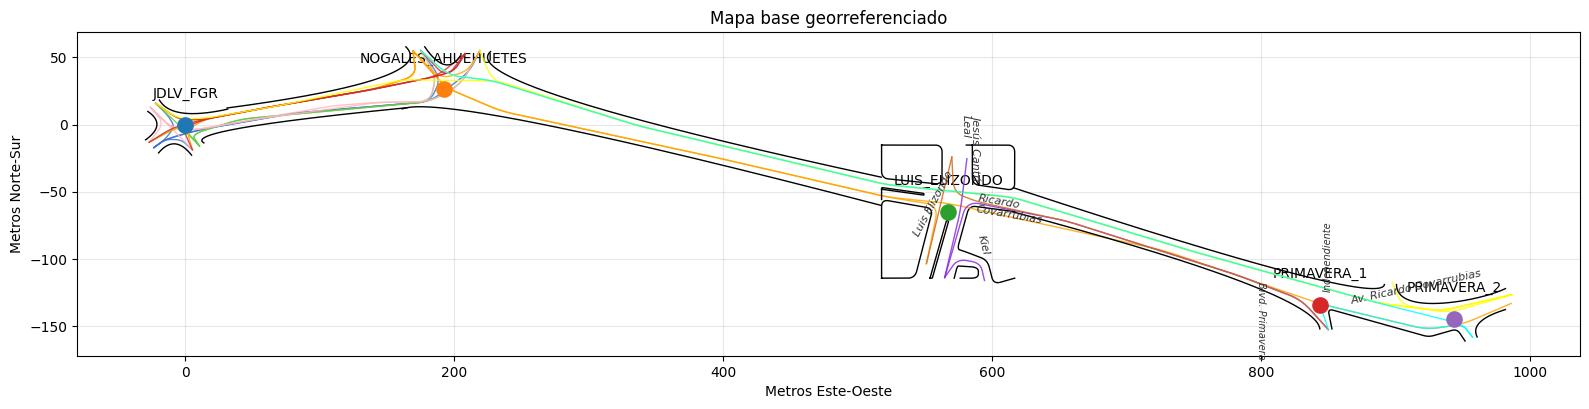

In [ ]:

# DIBUJO

fig, ax = plt.subplots(
    figsize=(16, 8)
)

# CORREDOR PRINCIPAL REAL

corridor = np.array([
    NODES["JDLV_FGR"],
    NODES["NOGALES_AHUEHUETES"],
    NODES["LUIS_ELIZONDO"],
    NODES["PRIMAVERA_1"],
    NODES["PRIMAVERA_2"]])

ax.plot(corridor[:, 0],corridor[:, 1],
    lw=5,alpha=0, # o 0.5
     zorder=1)

# NODOS

for name, p in NODES.items():

    ax.scatter(p[0],p[1],s=120,zorder=5)

    ax.text(p[0],p[1] + 20,name,ha='center')

# INTERSECCIONES SOBRE EL GPS REAL

plot_interseccion_02_local(ax,center=NODES["JDLV_FGR"],scale=0.57)

plot_ahuehuetes_nogales_local(ax,center=NODES["NOGALES_AHUEHUETES"],scale=0.35)

plot_primavera_covarrubias_local(ax,center=NODES["PRIMAVERA_1"],scale=3)

plot_luis_elizondo_covarrubias_local(ax,center=NODES["LUIS_ELIZONDO"],scale=0.45,
    x_shift=0,y_shift=0,lw=1)

# DISTANCIAS

names = list(NODES.keys())

for i in range(len(names)-1):
    p1 = NODES[names[i]]
    p2 = NODES[names[i+1]]
    d = np.linalg.norm(p2 - p1);

    print(
        f"{names[i]} -> {names[i+1]} = {d:.1f} m")

# COORDENADAS GLOBALES REALES (NUEVA ESCALA NORMALIZADA)

out_A = [-27, -13.2]
out_C = [5.2,-18.8]
out_F = [-22.2, 15.8]
out_J = [219, 55]
out_K = [850,-152.5]
out_L = [897.4,-117.3]
out_H = [175, 55]
out_N= [986,-133.1]
out_Q = [581.2,-25.4]
out_S = [551.1,-103.5]
out_T = [594.3,-116]

in_B = [-23.5, -17.2]
in_D = [10.4, -16]
in_E = [-26, 12.7]
in_G = [169.3, 54.7]
in_I = [208,52.7]
in_M = [957.3,-158.2]
in_O = [986.4,-126.6]
in_P = [570,-24.2]
in_R  =[564.7,-113.8]




TRAJECTORIES = {
    'azul': {
        'B_a_F': generate_waypoints([in_B, [-15,-11], [-8,-1.5], [-13,6.7],out_F], smooth_factor=10.0),
        'B_a_C': generate_waypoints([in_B, [-15,-11], [-3,-11.3], out_C], smooth_factor=10.0),
        'B_a_H': generate_waypoints([in_B, [-15,-11], [10, -4], [80, 8.4], [182,17],[190,34.4], out_H], smooth_factor=10),
        'B_a_J': generate_waypoints([in_B, [-15,-11], [10, -4], [80, 8.4], [182,17], [211, 39], out_J], smooth_factor=10),
    },
    'verde': {
        'D_a_F': generate_waypoints([in_D, [-3,-2], out_F], smooth_factor=4.0),
        'D_a_A': generate_waypoints([in_D, [-3.2,-0.25], out_A], smooth_factor=10.0),
        'D_a_H': generate_waypoints([in_D, [4.5, -7.3], [41,4], [182,17], [186.5,36],out_H], smooth_factor=10),
        'D_a_J': generate_waypoints([in_D, [4.5, -7.3], [41,4], [182,17], [205,30], out_J], smooth_factor=10.0),
   },
    'rosa': {
        'E_a_A': generate_waypoints([in_E, [-16, 1], out_A], smooth_factor=10.0),
        'E_a_C': generate_waypoints([in_E,[-10,-3], out_C], smooth_factor=10),
        'E_a_J': generate_waypoints([in_E, [-10,-3], [8,-4],  [46.5,3],[110,14],[143,16.5],[182,17],[205,30], out_J], smooth_factor=10),
        'E_a_H': generate_waypoints([in_E, [-10,-3], [8,-4],  [46.5,3], [143,16.5],[182,17],[186.5,36], out_H], smooth_factor=10),
    },
    'naranja':{
        'G_a_C': generate_waypoints([in_G, [171.6,36.3],[139,26],[71.5,14.6],[14.5,4],[1,-4.3], out_C],smooth_factor=10.0),
        'G_a_A': generate_waypoints([in_G,[171.6,36.3],[139,26],[71.5,14.6],[14.5,4], [-7.7,-2.8], out_A], smooth_factor=10.0),
        'G_a_J': generate_waypoints([in_G,[189.5,34],[209.7,39.4],out_J], smooth_factor=10.0),
        'G_a_F': generate_waypoints([in_G,[171.6,36.3],[139,26],[71.5,14.6],[14.5,4],[-4,3],out_F], smooth_factor=10.0),
        'G_a_S': generate_waypoints([in_G, [193.5,27.5],[234.5,10],[391.9,-23.9],[522,-54],[560,-60],out_S], smooth_factor = 10),
        'G_a_N': generate_waypoints([in_G,[193.5,27.5], [234.5,10],[391.9,-23.9],[522,-54],[566.5,-58.5],[727.2,-93.5],[843.7,-133.3],[923.2,-152.5],[950,-148.5],out_N],smooth_factor = 10)
    },
    'rojo': {
        'I_a_H': generate_waypoints([in_I,[194,34.7],out_H], smooth_factor=10.0),
        'I_a_C': generate_waypoints([in_I,[200,40],[187.5,36],[139,26],[71.5,14.6],[14.5,4],[-2,-3],out_C], smooth_factor=10.0),
        'I_a_A': generate_waypoints([in_I,[200,40],[187.5,36],[139,26],[71.5,14.6],[14.5,4],[-9,-2],out_A], smooth_factor=10.0),
        'I_a_F': generate_waypoints([in_I,[187.5,36],[139,26],[71.5,14.6],[14.5,4],[-4,3],out_F], smooth_factor=10.0),
    },
    'amarillo':{
        'O_a_L': generate_waypoints([in_O,[940,-140],[904.7,-134.5],out_L], smooth_factor=10.0),
        'O_a_J': generate_waypoints([in_O, [933.9,-138.7],[887.8,-133],[755.5,-96.2],[615.6,-54.15],[522,-44.9],[338,-1.3],[228,32.8],out_J], smooth_factor=10.0),
        'O_a_H': generate_waypoints([in_O, [933.9,-138.7],[887.8,-133],[755.5,-96.2],[615.6,-54.15],[522,-44.9],[338,-1.3],[228,32.8],[195.6,36.5],out_H], smooth_factor=10.0),
        'O_a_F': generate_waypoints([in_O, [933.9,-138.7],[887.8,-133],[755.5,-96.2],[615.6,-54.15],[522,-44.9],[338,-1.3],[232.8,32.4],[162,33.4],[70,14],[15,4.6],[-5.8,4.3],out_F], smooth_factor=10.0),
},
    'morado': {
        'R_a_T':generate_waypoints([in_R,[574.1,-100],[591.2,-103],out_T],smooth_factor=10.0),
        'R_a_S': generate_waypoints([in_R,[576.5,-64],out_Q]),
        'R_a_K': generate_waypoints([in_R,[581.1,-57],[654.4,-71.5],[781,-111.5],[829.6,-130],out_K], smooth_factor = 10)

    },
    'chocolate': {
        'P_a_S': generate_waypoints([in_P,out_S], smooth_factor=10.0),
        'P_a_K': generate_waypoints([in_P,[571.2,-50.4],[588.6,-57.4],[654.4,-71.5],[781,-111.5],[829.6,-130.2],out_K], smooth_factor=10.0)
    },
    'cyan':{
        'M_a_K': generate_waypoints([in_M,[950,-148.5],[923.2,-152.5],[843.7,-133.3],out_K],smooth_factor = 10),
        'M_a_H': generate_waypoints([in_M, [950,-148.5],[887.8,-133],[755.5,-96.2],[615.6,-54.15],[522,-44.9],[338,-1.3],[228,32.8],[195.6,36.5],out_H], smooth_factor = 10)
    }
}
# Configuración de colores por Origen/Sector
ORIGIN_COLORS = {
    'azul': '#3b71d1',
    'verde': '#66cc47',
    'rosa': 'lightpink',
    'rojo': '#d32f2f',
    'naranja': 'orange',
    'amarillo': 'yellow',
    'morado': '#8a2be2',
    'chocolate': 'chocolate',
    'cyan':'cyan',
}


# LÓGICA DE RENDERIZADO PARA EL DICCIONARIO
def plot_dictionary_trajectories(ax):
    """Recorre el diccionario TRAJECTORIES global y dibuja cada ruta."""
    for origin, routes in TRAJECTORIES.items():
        color = ORIGIN_COLORS.get(origin, 'black')
        for route_name, waypoints in routes.items():
            pts_array = np.array(waypoints)
            ax.plot(*pts_array.T, color=color, lw=1, alpha=0.85, zorder=3)

plot_dictionary_trajectories(ax)


ax.set_title( "Mapa base georreferenciado")

ax.set_xlabel("Metros Este-Oeste")
ax.set_ylabel("Metros Norte-Sur")

ax.grid(True, alpha=0.3)

ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Agentes inteligentes con probabilidad de aparición sin coordinación

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib.animation import FuncAnimation
from IPython import display


# 1. CONFIGURACIÓN E INFRAESTRUCTURA REAL

SPAWN_RATES = {
    "B": 0.05, "E": 0.04, "D": 0.033, "G": 0.023,
    "I": 0.02, "O": 0.017, "R": 0.01, "P": 0.01, "M": 0.007
}

MAPEO_ORIGEN_A_COLOR = {
    "B": "azul", "D": "verde", "E": "rosa", "G": "naranja",
    "I": "rojo", "O": "amarillo", "R": "morado", "P": "chocolate", "M": "cyan"
}

DISTANCIA_FRENADO_SEMAFORO = 10.0
DISTANCIA_MINIMA_VEHICULOS = 8.0
DISTANCIA_SENSOR_COLA = 35.0

# Posiciones oficiales en el eje del corredor principal
distancias_cruces = {
    "JDLV": 0.0,
    "Ahuehuetes": 167.0,
    "Ricardo": 562.0,
    "Primavera": 955.1
}


# 2. DICCIONARIO DE SEMÁFOROS

TODOS_SEMAFOROS = {
    "JDLV": {
        1: {"pos": [-9.32, -13.2], "rutas": ["B_a_F", "B_a_C", "B_a_H", "B_a_J"], "estado": "red", "cola_actual": 0},
        2: {"pos": [-21.4, 2.0],   "rutas": ["E_a_A", "E_a_C", "E_a_J", "E_a_H", "E_a_K"], "estado": "red", "cola_actual": 0},
        3: {"pos": [7.4, 8.0],     "rutas": ["G_a_C", "G_a_A", "G_a_F", "I_a_C", "I_a_A", "I_a_F", "O_a_F"], "estado": "green", "cola_actual": 0},
        4: {"pos": [11.45, -9.65], "rutas": ["D_a_F", "D_a_A", "D_a_H", "D_a_J"], "estado": "red", "cola_actual": 0}
    },
    "AHUEHUETES": {
        1: {"pos": [167.0, 13.0],  "rutas": ["C_a_J", "B_a_J", "D_a_J", 'E_a_A', 'E_a_C', 'E_a_J', 'E_a_H', 'D_a_F', 'D_a_A','D_a_H','B_a_H'], "estado": "green", "cola_actual": 0},
        2: {"pos": [167, 49],       "rutas": ['G_a_C', 'G_a_A', 'G_a_J', 'G_a_F', 'G_a_S', 'G_a_N'], "estado": "red", "cola_actual": 0},
        3: {"pos": [201.4, 46.0],  "rutas": ["I_a_H", "I_a_C", "I_a_A", "I_a_F"], "estado": "red", "cola_actual": 0},
        4: {"pos": [232.2, 40.0],  "rutas": ['O_a_J', 'O_a_H', 'O_a_F', 'M_a_H'], "estado": "red", "cola_actual": 0}
    },
    "RICARDO": {
        1: {"pos": [562.0, -40.2], "rutas": ["P_a_S", "P_a_K", 'P_a_L','P_a_N'], "estado": "green", "cola_actual": 0},
        2: {"pos": [589.0, -44.1], "rutas": ["O_a_J", "O_a_H", 'O_a_F','M_a_H'], "estado": "red", "cola_actual": 0},
        3: {"pos": [554.3, -65.0], "rutas": ["G_a_S", "G_a_N"], "estado": "red", "cola_actual": 0},
        4: {"pos": [579.5, -73.5], "rutas": ["R_a_T", "R_a_S", "R_a_K"], "estado": "red", "cola_actual": 0}
    },
    "PRIMAVERA": {
        1: {"pos": [955.1, -132.0], "rutas": ["O_a_L", "O_a_J", "O_a_H", "O_a_F"], "estado": "green", "cola_actual": 0},
        2: {"pos": [947.2, -153.7], "rutas": ["G_a_N"], "estado": "red", "cola_actual": 0}
    }
}



In [ ]:

# 3.  CLASE AGENTE SEMÁFORO

class AgenteSemaforo:
    def __init__(self, cruce_id, dicc_cruce, config_tiempos):
        """
        config_tiempos debe ser un diccionario con la estructura:
        { id_semaforo: {"green": frames, "yellow": frames, "all_red": frames} }
        """
        self.cruce_id = cruce_id
        self.dicc_cruce = dicc_cruce
        self.semaforos_ids = list(dicc_cruce.keys())
        self.config_tiempos = config_tiempos

        self.phase_idx = 0
        self.timer     = 0
        self.sub_phase = 'green'
        self._apply()

    def _apply(self):
        current_active_id = self.semaforos_ids[self.phase_idx]
        for id_sem, info in self.dicc_cruce.items():
            if self.sub_phase == 'green':
                info["estado"] = "green" if id_sem == current_active_id else "red"
            elif self.sub_phase == 'yellow':
                info["estado"] = "yellow" if id_sem == current_active_id else "red"
            else: # 'all_red'
                info["estado"] = "red"

    def step(self):
        self.timer += 1
        current_active_id = self.semaforos_ids[self.phase_idx]
        tiempos = self.config_tiempos[current_active_id]

        if self.sub_phase == 'green' and self.timer >= tiempos["green"]:
            self.sub_phase, self.timer = 'yellow', 0
        elif self.sub_phase == 'yellow' and self.timer >= tiempos["yellow"]:
            self.sub_phase, self.timer = 'all_red', 0
        elif self.sub_phase == 'all_red' and self.timer >= tiempos["all_red"]:
            # Cambiar al siguiente semáforo del cruce
            self.phase_idx = (self.phase_idx + 1) % len(self.semaforos_ids)
            self.sub_phase, self.timer = 'green', 0
        self._apply()


In [ ]:

# 4. CLASE VEHÍCULO

class Vehiculo:
    _id_global = 0
    def __init__(self, forzar_inicio_cero=False):
        Vehiculo._id_global += 1
        self.id = Vehiculo._id_global

        orígenes_demandas = list(SPAWN_RATES.keys())
        probabilidades = [SPAWN_RATES[o] for o in orígenes_demandas]
        prob_normalizadas = np.array(probabilidades) / sum(probabilidades)

        self.letra_origen = str(np.random.choice(orígenes_demandas, p=prob_normalizadas))
        self.grupo_origen = MAPEO_ORIGEN_A_COLOR[self.letra_origen]
        self.nombre_ruta = random.choice(list(TRAJECTORIES[self.grupo_origen].keys()))

        self.waypoints = np.array(TRAJECTORIES[self.grupo_origen][self.nombre_ruta])
        self.color = ORIGIN_COLORS.get(self.grupo_origen, '#000000')

        deltas = np.diff(self.waypoints, axis=0)
        distancias_segmentos = np.sqrt((deltas ** 2).sum(axis=1))
        self.distancia_acumulada = np.insert(np.cumsum(distancias_segmentos), 0, 0.0)
        self.distancia_total = self.distancia_acumulada[-1]

        self.velocidad_maxima = random.uniform(3.5, 5.5)
        self.velocidad_actual = self.velocidad_maxima

        self.distancia_actual = 0.0
        self.activo = True

        self.semaforos_afectados = []
        for cruce_id, dicc_sem in TODOS_SEMAFOROS.items():
            for sem_id, info in dicc_sem.items():
                if self.nombre_ruta in info["rutas"]:
                    self.semaforos_afectados.append((cruce_id, sem_id))

    def avanzar(self, otros_vehiculos):
        pos_actual = self.obtener_posicion()
        frenar = False

        pos_futura = self.obtener_posicion_en(self.distancia_actual + 2.0)
        vector_direccion = pos_futura - pos_actual
        norm_dir = np.linalg.norm(vector_direccion)
        if norm_dir > 0: vector_direccion /= norm_dir

        for o_veh in otros_vehiculos:
            if o_veh == self or not o_veh.activo: continue
            pos_otro = o_veh.obtener_posicion()
            dist_fisica = np.linalg.norm(pos_otro - pos_actual)
            # gestión anti-choques
            if dist_fisica < DISTANCIA_MINIMA_VEHICULOS + 8.0:
                vector_hacia_otro = pos_otro - pos_actual
                norm_hacia_otro = np.linalg.norm(vector_hacia_otro)
                if norm_hacia_otro > 0: vector_hacia_otro /= norm_hacia_otro
                dot_product = np.dot(vector_direccion, vector_hacia_otro)

                if dot_product > 0.65:
                    if self.nombre_ruta == o_veh.nombre_ruta:
                        if o_veh.distancia_actual >= self.distancia_actual:
                            frenar = True
                            break
                    else:
                        progreso_mio = self.distancia_actual / self.distancia_total
                        progreso_otro = o_veh.distancia_actual / o_veh.distancia_total
                        if progreso_otro > progreso_mio:
                            frenar = True
                            break
                        elif abs(progreso_mio - progreso_otro) < 0.05:
                            if id(self) < id(o_veh):
                                frenar = True
                                break

        if frenar:
            self.velocidad_actual = max(0.0, self.velocidad_actual - 0.6)
            if dist_fisica <= DISTANCIA_MINIMA_VEHICULOS: self.velocidad_actual = 0.0
        else:
            for cruce_id, sem_id in self.semaforos_afectados:
                info_sem = TODOS_SEMAFOROS[cruce_id][sem_id]
                if info_sem["estado"] in ["red", "yellow"]:
                    pos_sem = np.array(info_sem["pos"])
                    dist_al_sem = np.linalg.norm(pos_sem - pos_actual)

                    if dist_al_sem < DISTANCIA_FRENADO_SEMAFORO + 12.0:
                        if dist_al_sem > 2.5:
                            self.velocidad_actual = max(0.0, (dist_al_sem - DISTANCIA_FRENADO_SEMAFORO) * 0.35)
                        else:
                            self.velocidad_actual = 0.0
                        frenar = True
                        break

        if not frenar: self.velocidad_actual = min(self.velocidad_maxima, self.velocidad_actual + 0.25)
        self.distancia_actual += self.velocidad_actual
        if self.distancia_actual >= self.distancia_total: self.activo = False

    def obtener_posicion(self): return self.obtener_posicion_en(self.distancia_actual)
    def obtener_posicion_en(self, metraje):
        if not self.activo: return self.waypoints[-1]
        x_exacto = np.interp(metraje, self.distancia_acumulada, self.waypoints[:, 0])
        y_exacto = np.interp(metraje, self.distancia_acumulada, self.waypoints[:, 1])
        return np.array([x_exacto, y_exacto])


# 5. MATRICES DE TIEMPOS PERSONALIZADOS


# Configuración con ciclos de 120 FRAMES totales

config_jdlv = {
    1: {"green": 16, "yellow": 3, "all_red": 2},
    2: {"green": 16, "yellow": 3, "all_red": 2},
    3: {"green": 51, "yellow": 4, "all_red": 2},
    4: {"green": 16, "yellow": 3, "all_red": 2}
}

config_ahuehuetes = {
    1: {"green": 51, "yellow": 4, "all_red": 2},
    2: {"green": 16, "yellow": 3, "all_red": 2},
    3: {"green": 16, "yellow": 3, "all_red": 2},
    4: {"green": 16, "yellow": 3, "all_red": 2}
}

config_ricardo = {
    1: {"green": 16, "yellow": 3, "all_red": 2},
    2: {"green": 51, "yellow": 4, "all_red": 2},
    3: {"green": 16, "yellow": 3, "all_red": 2},
    4: {"green": 16, "yellow": 3, "all_red": 2}
}

config_primavera = {
    1: {"green": 84, "yellow": 4, "all_red": 2},
    2: {"green": 25, "yellow": 3, "all_red": 2}
}

# Instanciamos los nuevos agentes inteligentes con sus diccionarios asignados
lista_agentes = [
    AgenteSemaforo("JDLV", TODOS_SEMAFOROS["JDLV"], config_jdlv),
    AgenteSemaforo("AHUEHUETES", TODOS_SEMAFOROS["AHUEHUETES"], config_ahuehuetes),
    AgenteSemaforo("RICARDO", TODOS_SEMAFOROS["RICARDO"], config_ricardo),
    AgenteSemaforo("PRIMAVERA", TODOS_SEMAFOROS["PRIMAVERA"], config_primavera)]


In [ ]:
# 6.INICIALIZACIÓN DEL PELOTÓN

historico_tiempo = []
historico_autos = {}
historico_semaforos = {cruce: [] for cruce in distancias_cruces.keys()}

lista_vehiculos = []
num_vehiculos_iniciales = 30

# LÓGICA DE TRÁFICO CORREGIDA: Creamos un pelotón alineado estrictamente desde el origen (0m)
for i in range(num_vehiculos_iniciales):
    v = Vehiculo()
    # Hacemos que nazcan en fila india de forma negativa respecto al cero real de JDLV
    v.distancia_actual = 0.0 - (i * DISTANCIA_MINIMA_VEHICULOS * 1.3)
    lista_vehiculos.append(v)


# 7. ANIMACIÓN PRINCIPAL MATPLOTLIB

fig, ax = plt.subplots(figsize=(16, 8))

scat_sem = ax.scatter([], [], s=90, marker='8', edgecolors='#111111', linewidths=1.5, zorder=12)
scat = ax.scatter([], [], s=35, marker='o', edgecolors='white', linewidths=0.75, zorder=10)

# Pintar geometría estática
for name, p in NODES.items():
    ax.scatter(p[0], p[1], s=120, zorder=5, color='#333333')
    ax.text(p[0], p[1] + 20, name, ha='center', fontsize=9, weight='bold')
plot_interseccion_02_local(ax, center=NODES["JDLV_FGR"], scale=0.57)
plot_ahuehuetes_nogales_local(ax, center=NODES["NOGALES_AHUEHUETES"], scale=0.35)
plot_primavera_covarrubias_local(ax, center=NODES["PRIMAVERA_1"], scale=3)
plot_luis_elizondo_covarrubias_local(ax, center=NODES["LUIS_ELIZONDO"], scale=0.45, lw=1)

lista_total_x = [info["pos"][0] for dicc in TODOS_SEMAFOROS.values() for info in dicc.values()]
lista_total_y = [info["pos"][1] for dicc in TODOS_SEMAFOROS.values() for info in dicc.values()]
scat_sem.set_offsets(np.column_stack((lista_total_x, lista_total_y)))

def update(frame):
    global lista_vehiculos
    historico_tiempo.append(frame)

    # Avanzar semáforos por pasos de tiempo de sus configuraciones asignadas
    for agente in lista_agentes:
        agente.step()

    # Guardar los estados exactos de la arteria principal
    historico_semaforos["JDLV"].append(TODOS_SEMAFOROS["JDLV"][3]["estado"])
    historico_semaforos["Ahuehuetes"].append(TODOS_SEMAFOROS["AHUEHUETES"][1]["estado"])
    historico_semaforos["Ricardo"].append(TODOS_SEMAFOROS["RICARDO"][2]["estado"])
    historico_semaforos["Primavera"].append(TODOS_SEMAFOROS["PRIMAVERA"][1]["estado"])

    # Sensor de colas
    for id_cruce, dicc_sem in TODOS_SEMAFOROS.items():
        for id_sem, info in dicc_sem.items():
            contador_cola = 0
            pos_sem = np.array(info["pos"])
            for v in lista_vehiculos:
                if v.nombre_ruta in info["rutas"]:
                    dist = np.linalg.norm(pos_sem - v.obtener_posicion())
                    if dist < DISTANCIA_SENSOR_COLA and v.velocidad_actual < 0.5:
                        contador_cola += 1
            info["cola_actual"] = contador_cola

    # Flujo dinámico continuo
    if frame > 40 and random.random() < 0.15:
        lista_vehiculos.append(Vehiculo())

    vehiculos_activos = []
    coordenadas_x, coordenadas_y, colores_render = [], [], []

    for v in lista_vehiculos:
        v.avanzar(lista_vehiculos)
        if v.activo:
            vehiculos_activos.append(v)
            pos = v.obtener_posicion()
            coordenadas_x.append(pos[0])
            coordenadas_y.append(pos[1])
            colores_render.append(v.color)

            # SE REGISTRA DESDE EL CERO REAL GLOBAL
            if v.id not in historico_autos:
                historico_autos[v.id] = []

            # El avance ya es directo y proporcional sobre el eje
            pos_lineal_global = v.distancia_actual
            historico_autos[v.id].append((frame, pos_lineal_global))

    lista_vehiculos = vehiculos_activos
    colores_actuales_sem = [info["estado"] for dicc in TODOS_SEMAFOROS.values() for info in dicc.values()]
    scat_sem.set_facecolors(colores_actuales_sem)

    if coordenadas_x:
        scat.set_offsets(np.column_stack((coordenadas_x, coordenadas_y)))
        scat.set_facecolors(colores_render)
    else:
        scat.set_offsets(np.empty((0, 2)))

    return scat, scat_sem

ax.set_title("ANIMACIÓN CON TIEMPOS DE AGENTE ASIMÉTRICOS Y ARRANQUE EN M=0", weight='bold', fontsize=12)
ax.set_aspect('equal')
plt.tight_layout()

ani = FuncAnimation(fig, update, frames=1000, interval=35, blit=True)
display.HTML(ani.to_jshtml(fps=25))

### Diagrama espacio tiempo sin coordinación

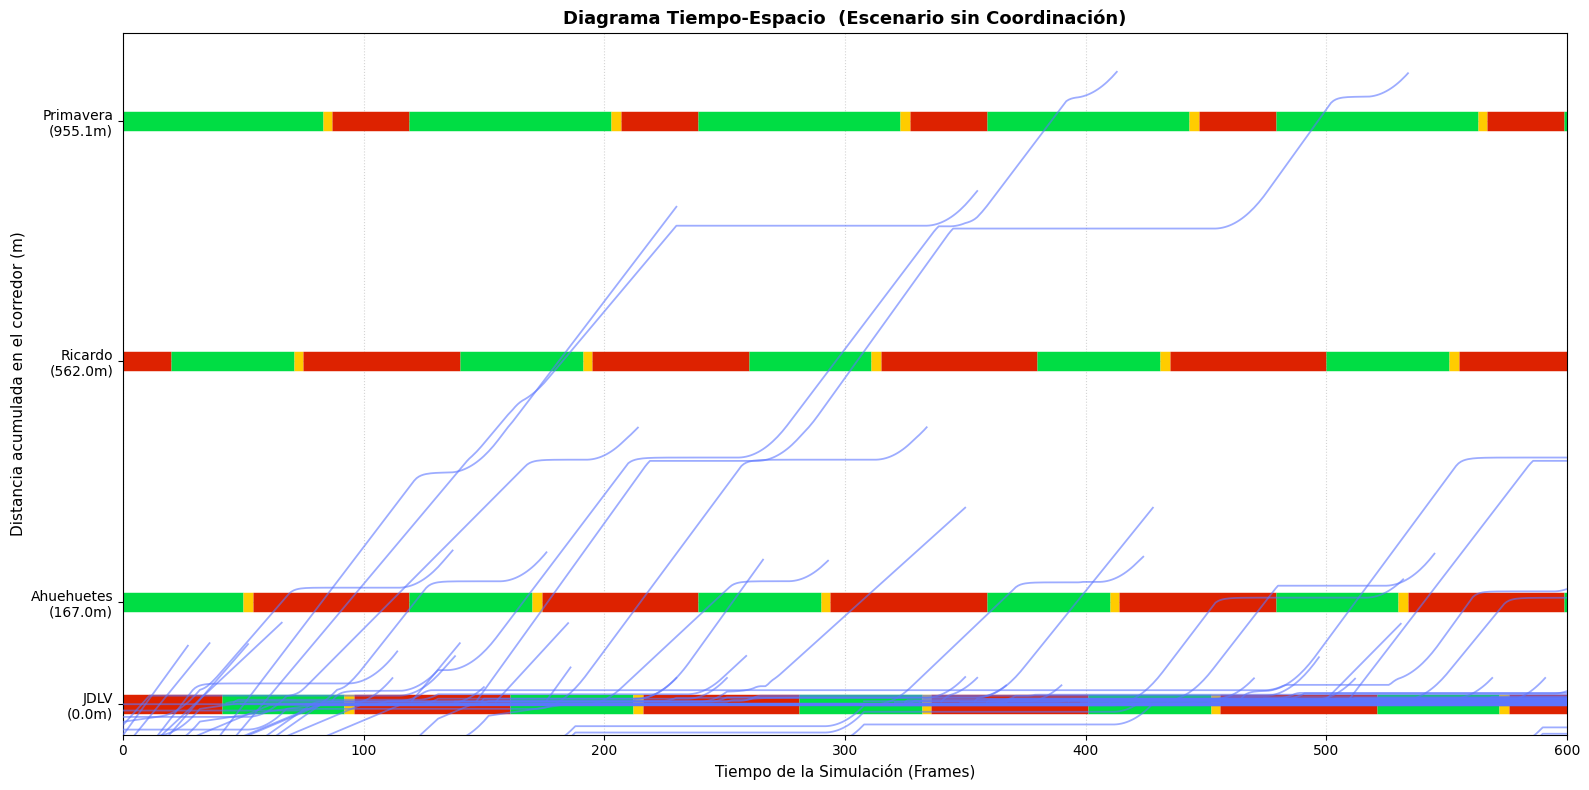

In [ ]:
fig2, ax2 = plt.subplots(figsize=(16, 8))

# 1. Graficar barras de semáforos
for nombre_cruce, pos_m in distancias_cruces.items():
    estados_cruce = historico_semaforos[nombre_cruce]
    t_inicio = 0
    for t in range(1, len(estados_cruce)):
        if estados_cruce[t] != estados_cruce[t_inicio] or t == len(estados_cruce) - 1:
            color_mapeado = '#00dd44' if estados_cruce[t_inicio] == 'green' else ('#ffcc00' if estados_cruce[t_inicio] == 'yellow' else '#dd2200')
            ax2.plot([t_inicio, t], [pos_m, pos_m], color=color_mapeado, lw=14, solid_capstyle='butt', zorder=2)
            t_inicio = t

# 2. Graficar trayectorias que nacen desde JDLV
for id_v, datos_trayectoria in historico_autos.items():
    if len(datos_trayectoria) > 2:
        t_coords = [pt[0] for pt in datos_trayectoria]
        pos_coords = [pt[1] for pt in datos_trayectoria]
        ax2.plot(t_coords, pos_coords, color='#5c76ff', alpha=0.6, lw=1.3, zorder=3)

ax2.set_title("Diagrama Tiempo-Espacio  (Escenario sin Coordinación)", weight='bold', fontsize=13)
ax2.set_xlabel("Tiempo de la Simulación", fontsize=11)
ax2.set_ylabel("Distancia acumulada en el corredor (m)", fontsize=11)
ax2.set_xlim(0, 600)
ax2.set_ylim(-50, 1100)

ax2.set_yticks(list(distancias_cruces.values()))
ax2.set_yticklabels([f"{k}\n({v}m)" for k, v in distancias_cruces.items()])
ax2.grid(True, linestyle=':', alpha=0.5, color='#aaaaaa')

plt.tight_layout()
plt.show()

# Sincronización Manual por Onda Verde
> previo a Q learning

In [ ]:
# VARIABLES CRÍTICAS GLOBALES
FPS = 25
DT = 1 / FPS
DISTANCIA_SENSOR_COLA = 40.0      #en metros
DISTANCIA_MINIMA_VEHICULOS = 5.0
DISTANCIA_FRENADO_SEMAFORO = 15.0
FRAMES_SIMULACION = 500

def reiniciar_metricas():
    global metricas, lista_vehiculos
    lista_vehiculos = []
    Vehiculo.contador_id = 0
    metricas = {
        "vehiculos_generados": 0, "vehiculos_completados": 0, "paradas_totales": 0,
        "tiempos_viaje": [], "paradas_individuales": [], "registros_tiempo_espacio": [],
        "trayectorias_xy": [], "historial_colas": [], "historial_recompensas": []
    }

In [ ]:

FPS = 25
DT = 1 / FPS

FRAMES_SIMULACION = 2000
# Métricas globales
metricas = {
    "vehiculos_generados": 0,
    "vehiculos_completados": 0,
    "paradas_totales": 0,
    "tiempos_viaje": [],
    "paradas_individuales": [],
    "registros_tiempo_espacio": [],
    "trayectorias_xy": [],
    "historial_colas": [],
    "historial_recompensas": []
}

In [ ]:
# 2. SELECCIÓN DE RUTA SEGÚN ORIGEN


def seleccionar_ruta_por_origen(letra_origen):
    grupo_origen = MAPEO_ORIGEN_A_COLOR[letra_origen]

    rutas_disponibles = list(TRAJECTORIES[grupo_origen].keys())

    # Filtrar rutas que empiezan con la letra correcta, si existen
    rutas_filtradas = [
        r for r in rutas_disponibles
        if r.startswith(letra_origen + "_a_")
    ]

    if len(rutas_filtradas) > 0:
        nombre_ruta = random.choice(rutas_filtradas)
    else:
        nombre_ruta = random.choice(rutas_disponibles)

    return grupo_origen, nombre_ruta

In [ ]:
class Vehiculo:
    contador_id = 0

    def __init__(self, letra_origen, frame_nacimiento=0):
        self.id = Vehiculo.contador_id
        Vehiculo.contador_id += 1

        self.letra_origen = letra_origen
        # Mapeo y selección de la ruta original
        self.grupo_origen, self.nombre_ruta = seleccionar_ruta_por_origen(letra_origen)

        self.waypoints = np.array(TRAJECTORIES[self.grupo_origen][self.nombre_ruta])
        self.color = ORIGIN_COLORS.get(self.grupo_origen, '#000000')

        # Cálculo de distancias acumuladas a lo largo de los waypoints
        deltas = np.diff(self.waypoints, axis=0)
        distancias_segmentos = np.sqrt((deltas ** 2).sum(axis=1))
        self.distancia_acumulada = np.insert(np.cumsum(distancias_segmentos), 0, 0.0)
        self.distancia_total = self.distancia_acumulada[-1]

        # Velocidad de diseño real (en m/s)
        self.velocidad_maxima = random.uniform(9.0, 13.0)  # ~32 a 47 km/h
        self.velocidad_actual = self.velocidad_maxima
        self.distancia_actual = 0.0
        self.activo = True

        self.frame_nacimiento = frame_nacimiento
        self.frame_salida = None

        self.estaba_detenido = False
        self.numero_paradas = 0

        self.semaforos_afectados = []
        for cruce_id, dicc_sem in TODOS_SEMAFOROS.items():
            for sem_id, info in dicc_sem.items():
                if self.nombre_ruta in info["rutas"]:
                    pos_sem = np.array(info["pos"])

                    # cuál es el waypoint más cercano al semáforo
                    distancias_nodos = np.linalg.norm(self.waypoints - pos_sem, axis=1)
                    indice_cercano = np.argmin(distancias_nodos)
                    metro_semaforo = self.distancia_acumulada[indice_cercano]
                    self.semaforos_afectados.append({
                        "cruce_id": cruce_id,
                        "sem_id": sem_id,
                        "metro_lineal": metro_semaforo
                    })

    def avanzar(self, otros_vehiculos, frame_actual):
        pos_actual = self.obtener_posicion()
        frenar = False

        # MECANISMO ANTICHOQUE
        pos_futura = self.obtener_posicion_en(self.distancia_actual + 1.0)
        vector_direccion = pos_futura - pos_actual
        norm_dir = np.linalg.norm(vector_direccion)
        if norm_dir > 0:
            vector_direccion /= norm_dir

        for o_veh in otros_vehiculos:
            if o_veh == self or not o_veh.activo:
                continue

            pos_otro = o_veh.obtener_posicion()
            dist_fisica = np.linalg.norm(pos_otro - pos_actual)

            if dist_fisica < DISTANCIA_MINIMA_VEHICULOS + 4.0:
                vector_hacia_otro = pos_otro - pos_actual
                norm_hacia_otro = np.linalg.norm(vector_hacia_otro)
                if norm_hacia_otro > 0:
                    vector_hacia_otro /= norm_hacia_otro

                dot_product = np.dot(vector_direccion, vector_hacia_otro)

                if dot_product > 0.65:
                    if self.nombre_ruta == o_veh.nombre_ruta:
                        if o_veh.distancia_actual >= self.distancia_actual:
                            frenar = True
                            break
                    else:
                        progreso_mio = self.distancia_actual / self.distancia_total
                        progreso_otro = o_veh.distancia_actual / o_veh.distancia_total
                        if progreso_otro > progreso_mio:
                            frenar = True
                            break
                        elif abs(progreso_mio - progreso_otro) < 0.05:
                            if self.id > o_veh.id:
                                frenar = True
                                break
        if not frenar:
            for sem_info in self.semaforos_afectados:
                cruce_id = sem_info["cruce_id"]
                sem_id = sem_info["sem_id"]
                metro_sem = sem_info["metro_lineal"]

                # ⭐ FILTRO DE ESCAPE: Si el frente del auto ya pasó el metro del semáforo, se ignora por completo
                if self.distancia_actual > metro_sem + 1.0:
                    continue

                info_sem = TODOS_SEMAFOROS[cruce_id][sem_id]

                if info_sem["estado"] in ["red", "yellow"]:
                    # La distancia al semáforo se mide sobre la línea de la trayectoria, no en línea recta euclidiana
                    dist_al_sem = metro_sem - self.distancia_actual

                    if 0.0 <= dist_al_sem < DISTANCIA_FRENADO_SEMAFORO + 12.0:
                        if dist_al_sem > 2.5:
                            self.velocidad_actual = max(0.0, (dist_al_sem - DISTANCIA_FRENADO_SEMAFORO) * 0.35)
                        else:
                            self.velocidad_actual = 0.0
                        frenar = True
                        break

        if frenar:
            self.velocidad_actual = max(0.0, self.velocidad_actual - 0.6)
        else:
            self.velocidad_actual = min(self.velocidad_maxima, self.velocidad_actual + 0.25)

        # Registro métrico de paradas
        if self.velocidad_actual < 0.5:
            if not self.estaba_detenido:
                self.numero_paradas += 1
                self.estaba_detenido = True
        else:
            self.estaba_detenido = False

        # el avance físico ahora respeta el tiempo diferencial real
        self.distancia_actual += self.velocidad_actual * DT
        pos = self.obtener_posicion()

        metricas["registros_tiempo_espacio"].append({
            "vehiculo_id": self.id,
            "frame": frame_actual,
            "tiempo": frame_actual / FPS,
            "distancia": pos[0], # Registra la componente x absoluta para el mapeo del corredor
            "ruta": self.nombre_ruta,
            "origen": self.letra_origen,
            "velocidad": self.velocidad_actual
        })

        metricas["trayectorias_xy"].append({
            "vehiculo_id": self.id,
            "frame": frame_actual,
            "x": pos[0],
            "y": pos[1],
            "origen": self.letra_origen,
            "ruta": self.nombre_ruta
        })

        if self.distancia_actual >= self.distancia_total:
            self.activo = False
            self.frame_salida = frame_actual

            metricas["vehiculos_completados"] += 1
            metricas["paradas_totales"] += self.numero_paradas
            metricas["paradas_individuales"].append(self.numero_paradas)
            metricas["tiempos_viaje"].append((self.frame_salida - self.frame_nacimiento) / FPS)

    def obtener_posicion(self):
        return self.obtener_posicion_en(self.distancia_actual)

    def obtener_posicion_en(self, metraje):
        if not self.activo:
            return self.waypoints[-1]
        x_exacto = np.interp(metraje, self.distancia_acumulada, self.waypoints[:, 0])
        y_exacto = np.interp(metraje, self.distancia_acumulada, self.waypoints[:, 1])
        return np.array([x_exacto, y_exacto])

In [ ]:

# 4. FUNCIÓN DE INYECCIÓN POR ORIGEN
def inyectar_vehiculos(frame_actual):
    nuevos = []

    for origen, tasa in SPAWN_RATES.items():
        if random.random() < tasa:
            nuevos.append(Vehiculo(origen, frame_nacimiento=frame_actual))
            metricas["vehiculos_generados"] += 1

    return nuevos

In [ ]:

# 5. CONTROL SEMAFÓRICO CON INGENIERÍA DE ONDA VERDE

# Velocidad de sincronía: 40 km/h = 11.11 m/s
VELOCIDAD_SINCRONIA_MS = 40.0 / 3.6

# Distancias reales desde JDLV (metros)
DIST = {
    "JDLV":      0.0,
    "AHUEHUETES": 193.8,
    "RICARDO":    580.0,
    "PRIMAVERA":  965.4
}

# offset = (distancia / velocidad) * FPS
OFFSETS_FISICOS = {
    cruce: int((d / VELOCIDAD_SINCRONIA_MS) * FPS)
    for cruce, d in DIST.items()
}

# Ciclo único
CICLO_UNICO  = 240
SPLIT_VERDE  = 96

CONFIG_SEMAFOROS = {
    "JDLV": {
        "ciclo":          CICLO_UNICO,
        "duracion_verde": SPLIT_VERDE,
        "offset":         OFFSETS_FISICOS["JDLV"]
    },
    "AHUEHUETES": {
        "ciclo":          CICLO_UNICO,
        "duracion_verde": SPLIT_VERDE,
        "offset":         OFFSETS_FISICOS["AHUEHUETES"]
    },
    "RICARDO": {
        "ciclo":          CICLO_UNICO,
        "duracion_verde": SPLIT_VERDE,
        "offset":         OFFSETS_FISICOS["RICARDO"]
    },
    "PRIMAVERA": {
        "ciclo":          CICLO_UNICO,
        "duracion_verde": SPLIT_VERDE,
        "offset":         OFFSETS_FISICOS["PRIMAVERA"]
    }
}


def actualizar_semaforos(frame):
    for id_cruce, dicc_sem in TODOS_SEMAFOROS.items():
        config = CONFIG_SEMAFOROS[id_cruce]
        ciclo  = config["ciclo"]
        verde  = config["duracion_verde"]
        offset = config["offset"]

        # Tiempo local del cruce
        tiempo_local = (frame + offset) % ciclo

        num_semaforos = len(dicc_sem)
        fase_activa = int(tiempo_local // verde) % num_semaforos

        for id_sem, info in dicc_sem.items():
            info["estado"] = "green" if id_sem == fase_activa + 1 else "red"

# Imprimir offsets para verificación
print("Offsets físicos calculados:")
for cruce, off in OFFSETS_FISICOS.items():
    print(f"  {cruce:<14} → {off:5d} frames = {off/FPS:.2f} s  "
          f"(mod ciclo = {off % CICLO_UNICO} frames = {(off % CICLO_UNICO)/FPS:.2f} s)")

print(f"\nCiclo único    : {CICLO_UNICO} frames = {CICLO_UNICO/FPS:.1f} s")
print(f"Split verde    : {SPLIT_VERDE} frames = {SPLIT_VERDE/FPS:.2f} s ({SPLIT_VERDE/CICLO_UNICO*100:.0f}%)")
print(f"Velocidad sync : {VELOCIDAD_SINCRONIA_MS*3.6:.0f} km/h")

Offsets físicos calculados:
  JDLV           →     0 frames = 0.00 s  (mod ciclo = 0 frames = 0.00 s)
  AHUEHUETES     →   360 frames = 14.40 s  (mod ciclo = 120 frames = 4.80 s)
  RICARDO        →  1248 frames = 49.92 s  (mod ciclo = 48 frames = 1.92 s)
  PRIMAVERA      →  2133 frames = 85.32 s  (mod ciclo = 213 frames = 8.52 s)

Ciclo único    : 240 frames = 9.6 s
Split verde    : 96 frames = 3.84 s (40%)
Velocidad sync : 40 km/h


In [ ]:

# 6. SENSOR DE COLAS
def actualizar_colas(lista_vehiculos):
    for id_cruce, dicc_sem in TODOS_SEMAFOROS.items():
        for id_sem, info in dicc_sem.items():

            contador_cola = 0
            pos_sem = np.array(info["pos"])

            for v in lista_vehiculos:
                if v.nombre_ruta in info["rutas"]:
                    dist = np.linalg.norm(pos_sem - v.obtener_posicion())

                    if dist < DISTANCIA_SENSOR_COLA and v.velocidad_actual < 0.5:
                        contador_cola += 1

            info["cola_actual"] = contador_cola


In [ ]:

# 7. UPDATE COMPLETO DE SIMULACIÓN
lista_vehiculos = []

def update(frame):
    global lista_vehiculos

    # 1. Actualizar semáforos
    actualizar_semaforos(frame)

    # 2. Actualizar sensores de cola
    actualizar_colas(lista_vehiculos)
    cola_total = sum(
          info["cola_actual"]
          for dicc in TODOS_SEMAFOROS.values()
          for info in dicc.values())

    metricas["historial_colas"].append({
          "frame": frame,
          "tiempo": frame / FPS,
          "cola_total": cola_total})

      # Recompensa simple del SMA
    recompensa_frame = (
          metricas["vehiculos_completados"] * 10
          - metricas["paradas_totales"] * 2
          - cola_total
      )

    metricas["historial_recompensas"].append(recompensa_frame)

    # Inyectar vehículos según tasas por origen
    nuevos_vehiculos = inyectar_vehiculos(frame)
    lista_vehiculos.extend(nuevos_vehiculos)

    # 4. Avanzar vehículos
    vehiculos_activos = []
    coordenadas_x = []
    coordenadas_y = []
    colores_render = []

    for v in lista_vehiculos:
        v.avanzar(lista_vehiculos, frame)

        if v.activo:
            vehiculos_activos.append(v)
            pos = v.obtener_posicion()
            coordenadas_x.append(pos[0])
            coordenadas_y.append(pos[1])
            colores_render.append(v.color)

    lista_vehiculos = vehiculos_activos

    # 5. Render vehículos
    if coordenadas_x:
        scat.set_offsets(np.column_stack((coordenadas_x, coordenadas_y)))
        scat.set_facecolors(colores_render)
    else:
        scat.set_offsets(np.empty((0, 2)))

    colores_actuales_sem = [
        info["estado"]
        for dicc in TODOS_SEMAFOROS.values()
        for info in dicc.values()
    ]

    scat_sem.set_facecolors(colores_actuales_sem)

    return scat, scat_sem

In [ ]:
# 8. ANIMACIÓN

ani = FuncAnimation(
    fig,
    update,
    frames=int(FRAMES_SIMULACION),
    interval=35,
    blit=True)
display.HTML(ani.to_jshtml(fps=25))

In [ ]:

# 9. MÉTRICAS DE EFICIENCIA

veh_completados = metricas["vehiculos_completados"]

if veh_completados > 0:
    promedio_paradas = metricas["paradas_totales"] / veh_completados
    tiempo_promedio = np.mean(metricas["tiempos_viaje"])
else:
    promedio_paradas = 0
    tiempo_promedio = 0

print("==================================================")
print("         MÉTRICAS DE EFICIENCIA DEL MODELO SMA")
print("==================================================")
print(f" - Vehículos generados: {metricas['vehiculos_generados']}")
print(f" - Vehículos que completaron su viaje: {veh_completados}")
print(f" - Promedio de paradas por vehículo: {promedio_paradas:.2f}")
print(f" - Tiempo promedio de viaje: {tiempo_promedio:.2f} segundos")

if promedio_paradas <= 1.5:
    estado = "OPTIMIZADA"
elif promedio_paradas <= 2.5:
    estado = "ACEPTABLE"
else:
    estado = "NO OPTIMIZADA"

print(f" -> Estado de la Onda Verde: {estado}")

         MÉTRICAS DE EFICIENCIA DEL MODELO SMA
 -> Vehículos generados: 410
 -> Vehículos que completaron su viaje: 62
 -> Promedio de paradas por vehículo: 2.23
 -> Tiempo promedio de viaje: 24.75 segundos
 -> Estado de la Onda Verde: ACEPTABLE


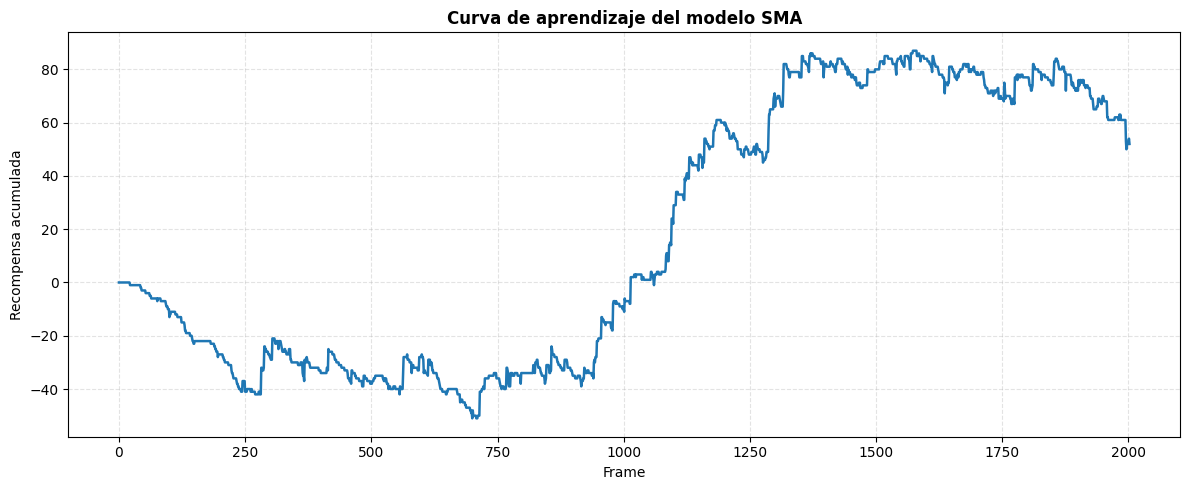

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(metricas["historial_recompensas"], linewidth=1.8)

plt.xlabel("Frame")
plt.ylabel("Recompensa acumulada")
plt.title("Dinámica de la Recompensa Instantánea", weight="bold")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

# Q-Learning SMA: Agente Centralizado con Telemetría

In [ ]:

# 10. CONFIGURACIÓN Q-LEARNING — ESTADO + ACCIONES

import itertools, time
import numpy as np
import random

CRUCES_Q = ["JDLV", "AHUEHUETES", "RICARDO", "PRIMAVERA"]

# Física real del corredor
VELOCIDAD_SINCRONIA_MS = 40.0 / 3.6
DISTANCIAS_CORREDOR_M = {
    "JDLV":      0.0,
    "AHUEHUETES": 193.8,
    "RICARDO":    580.0,
    "PRIMAVERA":  965.1
}

FPS_QL = 25
CICLO_BASE = 240

# Offsets físicos calculados: delta_dist / v_sincronia
def offset_fisico(cruce_destino):
    dist = DISTANCIAS_CORREDOR_M[cruce_destino] - DISTANCIAS_CORREDOR_M["JDLV"]
    segundos = dist / VELOCIDAD_SINCRONIA_MS
    return int(segundos * FPS_QL)

OFFSET_FISICO = {c: offset_fisico(c) for c in CRUCES_Q}
print("Offsets físicos base (frames):")
for k, v in OFFSET_FISICO.items():
    print(f"  {k}: {v} frames = {v/FPS_QL:.2f} s")

#  Espacio de acciones: perturbaciones alrededor del óptimo físico
# 5 perturbaciones * 3 cruces ajustables = 125 acciones
PERTURBACIONES_F = [0, -20, 20, -40, 40]   # frames

ACCIONES_QL = [
    (0,
     OFFSET_FISICO["AHUEHUETES"] + da,
     OFFSET_FISICO["RICARDO"]    + dr,
     OFFSET_FISICO["PRIMAVERA"]  + dp)
    for da in PERTURBACIONES_F
    for dr in PERTURBACIONES_F
    for dp in PERTURBACIONES_F
]
N_ACCIONES_QL = len(ACCIONES_QL)
print(f"\nEspacio de acciones: {N_ACCIONES_QL}")

# Espacio de estados: 3 niveles de cola × 4 cruces = 81 estados
# (cola_JDLV, cola_AHU, cola_RIC, cola_PRI) cada uno en {0,1,2}
def discretizar_cola(n):
    if n < 3:  return 0
    if n < 7:  return 1
    return 2

def obtener_estado_global():
    """Lee las colas actuales de cada cruce y devuelve tupla discreta."""
    estado = []
    for cruce in CRUCES_Q:
        total_cola = sum(
            info["cola_actual"]
            for info in TODOS_SEMAFOROS[cruce].values()
        )
        estado.append(discretizar_cola(total_cola))
    return tuple(estado)

#  Tabla Q como diccionario
Q_TABLE = {}

def get_q(estado):
    if estado not in Q_TABLE:
        # Inicialización informada: sesgo hacia el centro (acción 62 ≈ offsets físicos puros)
        Q_TABLE[estado] = np.zeros(N_ACCIONES_QL)
    return Q_TABLE[estado]

print("\nQ-Table inicializada como diccionario vacío (lazy).")
print("Estado ejemplo:", obtener_estado_global() if 'TODOS_SEMAFOROS' in dir() else "(ejecutar luego)")


Offsets físicos base (frames):
  JDLV: 0 frames = 0.00 s
  AHUEHUETES: 436 frames = 17.44 s
  RICARDO: 1305 frames = 52.20 s
  PRIMAVERA: 2171 frames = 86.84 s

Espacio de acciones: 125

Q-Table inicializada como diccionario vacío (lazy).
Estado ejemplo: (2, 2, 2, 0)


In [ ]:

# 11. APLICAR OFFSETS A CONFIG_SEMAFOROS

def aplicar_offsets(offsets):
    for cruce, offset in zip(CRUCES_Q, offsets):
        CONFIG_SEMAFOROS[cruce]["offset"] = int(offset) % CICLO_BASE


In [ ]:

# 12. REINICIAR MÉTRICAS POR EPISODIO

def reiniciar_metricas():
    global metricas, lista_vehiculos

    lista_vehiculos = []
    Vehiculo.contador_id = 0

    metricas = {
        "vehiculos_generados": 0,
        "vehiculos_completados": 0,
        "paradas_totales": 0,
        "tiempos_viaje": [],
        "paradas_individuales": [],
        "registros_tiempo_espacio": [],
        "trayectorias_xy": [],
        "historial_colas": [],
        "historial_recompensas": []
    }

In [ ]:

# 13. SIMULAR EPISODIO SIN ANIMACIÓN — RECOMPENSA ONDA VERDE

FRAMES_ENTRENAMIENTO = 800

def simular_episodio(offsets, frames=FRAMES_ENTRENAMIENTO):
    global lista_vehiculos

    reiniciar_metricas()
    aplicar_offsets(offsets)

    paradas_arteria = 0

    for frame in range(frames):
        actualizar_semaforos(frame)
        actualizar_colas(lista_vehiculos)

        cola_total = sum(
            info.get("cola_actual", 0)
            for dicc in TODOS_SEMAFOROS.values()
            for info in dicc.values()
        )
        metricas["historial_colas"].append({"frame": frame, "tiempo": frame / FPS, "cola_total": cola_total})

        nuevos_vehiculos = inyectar_vehiculos(frame)
        lista_vehiculos.extend(nuevos_vehiculos)

        vehiculos_activos = []
        for v in lista_vehiculos:
            v.avanzar(lista_vehiculos, frame)
            if v.activo:
                vehiculos_activos.append(v)

        lista_vehiculos = vehiculos_activos

    # Calcular métricas de onda verde
    exitosos = metricas["vehiculos_completados"]
    paradas = metricas["paradas_totales"]

    # Vehículos que no pararon en la arteria principal
    paradas_individuales = metricas["paradas_individuales"]
    sin_parada = sum(1 for p in paradas_individuales if p == 0)

    tiempo_promedio = np.mean(metricas["tiempos_viaje"]) if metricas["tiempos_viaje"] else FRAMES_ENTRENAMIENTO / FPS
    cola_promedio = np.mean([c["cola_total"] for c in metricas["historial_colas"]]) if metricas["historial_colas"] else 0

    recompensa = (
        sin_parada  * 100    # Premio fuerte por flujo continuo
        + exitosos  * 50     # Premio por completar viaje
        - paradas   * 0.5   # Penalización paradas totales
        - cola_promedio * 5  # Penalización congestionamiento
        - tiempo_promedio * 0.1
    )

    return recompensa, exitosos, paradas, tiempo_promedio


In [ ]:
import numpy as np
import random


# 14. ENTRENAMIENTO Q-LEARNING CON ESTADO REAL

EPISODES = 200
alpha    = 0.15       # learning rate
gamma    = 0.9         # discount
epsilon  = 1.0
epsilon_min   = 0.05
epsilon_decay = 0.995  # decae en ~150 episodios

# Early Stopping Parameters
patience = 70 # Number of episodes to wait for improvement
min_delta = 5 # Minimum change in reward to qualify as an improvement

best_reward_so_far = -np.inf
epochs_no_improve = 0

reward_history  = []
success_history = []
stop_history    = []
time_history    = []
offset_history  = []
state_history   = []

inicio_total = time.time()

for episodio in range(EPISODES):
    inicio_ep = time.time()

    # Percepción del estado ANTES del episodio
    # Usar el estado al final del episodio anterior
    if episodio == 0:
        estado_previo = (0, 0, 0, 0)

    q_vals = get_q(estado_previo)
    if random.random() < epsilon:
        action_idx = random.randint(0, N_ACCIONES_QL - 1)
    else:
        action_idx = int(np.argmax(q_vals))

    offsets = ACCIONES_QL[action_idx]

    # Simular episodio
    recompensa, exitosos, paradas, tiempo_promedio = simular_episodio(
        offsets, frames=FRAMES_ENTRENAMIENTO
    )

    # Estado DESPUÉS del episodio
    estado_nuevo = obtener_estado_global()

    # Actualización de Bellman
    q_actual  = Q_TABLE[estado_previo][action_idx]
    q_futuro  = np.max(get_q(estado_nuevo))
    Q_TABLE[estado_previo][action_idx] = q_actual + alpha * (recompensa + gamma * q_futuro - q_actual)

    # Guardar historial
    reward_history.append(recompensa)
    success_history.append(exitosos)
    stop_history.append(paradas)
    time_history.append(tiempo_promedio)
    offset_history.append(offsets)
    state_history.append(estado_previo)

    estado_previo = estado_nuevo
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Early Stopping
    if recompensa > best_reward_so_far + min_delta:
        best_reward_so_far = recompensa
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at episode {episodio} due to no improvement for {patience} episodes.")
        break

    if episodio % 5 == 0:
        dur = time.time() - inicio_ep
        print(f"Ep {episodio:3d}/{EPISODES} | R={recompensa:8.1f} | Exitosos={exitosos:3d} | "
              f"Paradas={paradas:4d} | ε={epsilon:.3f} | Estado={estado_previo} | {dur:.1f}s")

dur_total = (time.time() - inicio_total) / 60
print(f"\n{'='*55}")
print(f"Entrenamiento terminado en {dur_total:.2f} min")
print(f"Estados visitados: {len(Q_TABLE)}")
print(f"{'='*55}")

NameError: name 'time' is not defined

In [ ]:

# 15. OFFSETS APRENDIDOS — MEJOR EPISODIO

best_episode_idx   = int(np.argmax(reward_history))
best_offsets       = np.array(offset_history[best_episode_idx])
best_reward        = reward_history[best_episode_idx]
best_offsets_sec   = best_offsets / FPS

print("=" * 55)
print("   OFFSETS APRENDIDOS POR Q-LEARNING (ESTADO REAL)")
print("=" * 55)
for cruce, off_f, off_s in zip(CRUCES_Q, best_offsets, best_offsets_sec):
    off_fisico_s = OFFSET_FISICO[cruce] / FPS
    print(f"  {cruce:<14} | {off_f:4d} frames | {off_s:.2f} s  (físico: {off_fisico_s:.2f} s)")
print("-" * 55)
print(f"  Mejor recompensa : {best_reward:.1f}")
print(f"  Episodio         : {best_episode_idx}")
print(f"  Estado en ese ep : {state_history[best_episode_idx]}")
print("=" * 55)


In [ ]:

# 16. CURVAS DE APRENDIZAJE

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(reward_history)
plt.title("Recompensa")
plt.xlabel("Episodio")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(success_history)
plt.title("Vehículos exitosos")
plt.xlabel("Episodio")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(stop_history)
plt.title("Paradas")
plt.xlabel("Episodio")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

horizonte_tiempo = 160
tamaño_peloton = 30
separacion_salida = 0.7

# Variables de entorno originales
duracion_ciclo_seg = CICLO_BASE / FPS_QL
tiempo_verde_seg = duracion_ciclo_seg * 0.50

lista_distancias = [DISTANCIAS_CORREDOR_M[cruce] for cruce in CRUCES_Q]
offsets_segundos = [off_frames / FPS_QL for off_frames in best_offsets]
ideal_arrival_times = np.array([dist / VELOCIDAD_SINCRONIA_MS for dist in lista_distancias])
fig_diag, ax_diag = plt.subplots(figsize=(14, 8), facecolor='#f5f0e8')
ax_diag.set_facecolor('#faf7f2')

for idx, cruce in enumerate(CRUCES_Q):
    distancia_y = lista_distancias[idx]
    offset_cruce_seg = offsets_segundos[idx]

    ax_diag.axhline(y=distancia_y, color='#999999', linestyle='--', alpha=0.25, zorder=1)
    ax_diag.text(horizonte_tiempo + 2, distancia_y, cruce.replace("_", " "),
                 fontsize=9, va='center', weight='bold', color='#333333')
    tiempo_ciclo_iter = -duracion_ciclo_seg * 2
    while tiempo_ciclo_iter < horizonte_tiempo:
        inicio_verde = tiempo_ciclo_iter + offset_cruce_seg
        fin_verde = inicio_verde + tiempo_verde_seg
        fin_ciclo = inicio_verde + duracion_ciclo_seg

        v_start, v_end = max(0, inicio_verde), min(horizonte_tiempo, fin_verde)
        r_start, r_end = max(0, fin_verde), min(horizonte_tiempo, fin_ciclo)

        if v_start < v_end:
            ax_diag.plot([v_start, v_end], [distancia_y, distancia_y],
                         color='#22c55e', linewidth=7, alpha=0.85, solid_capstyle='butt', zorder=2)
        if r_start < r_end:
            ax_diag.plot([r_start, r_end], [distancia_y, distancia_y],
                         color='#ef4444', linewidth=7, alpha=0.85, solid_capstyle='butt', zorder=2)

        tiempo_ciclo_iter += duracion_ciclo_seg
for car_id in range(tamaño_peloton):
    # Cada auto arranca desfasado únicamente por su tiempo de salida (headway)
    start_t = car_id * separacion_salida

    times = start_t + ideal_arrival_times

    # Graficar las líneas continuas
    if car_id == 0:
        ax_diag.plot(times, lista_distancias, color='#1b3a4b', linewidth=2.5, alpha=1.0,
                     zorder=5, label='Líder del Pelotón (Auto 1)')
    elif car_id == tamaño_peloton - 1:
        ax_diag.plot(times, lista_distancias, color='#ef4444', linewidth=2.5, alpha=1.0,
                     zorder=5, label='Cola del Pelotón (Auto 25)')
    else:
        ax_diag.plot(times, lista_distancias, color='#3a86c8', linewidth=0.8, alpha=0.25, zorder=4)

ax_diag.set_title("DIAGRAMA TIEMPO–ESPACIO Q LEARNING",
                  weight="bold", fontsize=13, color='black', pad=15)
ax_diag.set_xlabel("Tiempo (s)", fontsize=11, labelpad=8)
ax_diag.set_ylabel("Distancia acumulada en el corredor (m)", fontsize=11, labelpad=8)

ax_diag.set_xlim(0, horizonte_tiempo)
ax_diag.set_ylim(-40, lista_distancias[-1] + 60)
ax_diag.grid(True, linestyle='--', alpha=0.25, color='#999999')

for spine in ax_diag.spines.values():
    spine.set_visible(False)

ax_diag.legend(loc='upper left', facecolor='#ffffff', edgecolor='none', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams['animation.embed_limit'] = 25.0

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython import display as ipy_display
import numpy as np

aplicar_offsets(best_offsets)
reiniciar_metricas()
lista_vehiculos_onda = []

fig_onda, ax_onda = plt.subplots(figsize=(18, 7), facecolor='#f5f0e8')
ax_onda.set_facecolor('#faf7f2')

# Infraestructura
corridor = np.array([
    NODES["JDLV_FGR"], NODES["NOGALES_AHUEHUETES"],
    NODES["LUIS_ELIZONDO"], NODES["PRIMAVERA_1"], NODES["PRIMAVERA_2"]
])
ax_onda.plot(corridor[:,0], corridor[:,1], lw=6, alpha=0.15, color='white', zorder=1)

for origin, routes in TRAJECTORIES.items():
    col = ORIGIN_COLORS.get(origin, 'gray')
    for wps in routes.values():
        pts = np.array(wps)
        ax_onda.plot(pts[:,0], pts[:,1], color=col, lw=0.8, alpha=0.12, zorder=2)

plot_interseccion_02_local(ax_onda, center=NODES["JDLV_FGR"], scale=0.57)
plot_ahuehuetes_nogales_local(ax_onda, center=NODES["NOGALES_AHUEHUETES"], scale=0.35)
plot_primavera_covarrubias_local(ax_onda, center=NODES["PRIMAVERA_1"], scale=3)
plot_luis_elizondo_covarrubias_local(ax_onda, center=NODES["LUIS_ELIZONDO"],
                                      scale=0.45, x_shift=0, y_shift=0, lw=1)

# Nombres de nodos
for name, p in NODES.items():
    ax_onda.text(p[0], p[1]+22, name.replace("_"," "), ha='center',
             fontsize=8, weight='bold', color='#333333', zorder=6)

# Semáforos
sem_xs = [info["pos"][0] for dicc in TODOS_SEMAFOROS.values() for info in dicc.values()]
sem_ys = [info["pos"][1] for dicc in TODOS_SEMAFOROS.values() for info in dicc.values()]

sem_halo = ax_onda.scatter(sem_xs, sem_ys, s=260, marker='o', zorder=11,
                            edgecolors='white', linewidths=0.8, alpha=0.3)
scat_sem_onda = ax_onda.scatter(sem_xs, sem_ys, s=130, marker='o',
                                 edgecolors='white', linewidths=1.0, zorder=12)

# Vehículos
scat_onda = ax_onda.scatter([], [], s=50, marker='o',
                              edgecolors='white', linewidths=0.6, zorder=10)

# Panel de texto superior
info_txt = ax_onda.text(
    0.01, 0.97, "", transform=ax_onda.transAxes,
    fontsize=9, color='#1a1a1a', va='top', family='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffffff', alpha=0.85)
)

# Leyenda de onda verde
legend_elems = [
    mpatches.Patch(color='#00ff88', label='Flujo verde (0 paradas)'),
    mpatches.Patch(color='#ff4444', label='Detenido en rojo'),
    mpatches.Patch(color='#ffaa00', label='Desacelerando'),
]
ax_onda.legend(handles=legend_elems, loc='lower right',
               facecolor='#ffffff', labelcolor='#1a1a1a', fontsize=8)

ax_onda.set_xlim(-120, 1060)
ax_onda.set_ylim(-220, 95)
ax_onda.set_aspect('equal')
for spine in ax_onda.spines.values():
    spine.set_visible(False)
ax_onda.grid(True, linestyle='--', alpha=0.25, color='#999999')
ax_onda.set_title("ONDA VERDE — CORREDOR SINCRONIZADO (Q-Learning SMA)",
                   weight='bold', fontsize=13, color='black', pad=12)

frame_onda_counter = [0]

MULTIPLICADOR_TIEMPO = 4.0  # para acelerar la visualización

def update_onda(frame):
    global lista_vehiculos_onda
    frame_onda_counter[0] = frame

    #Multiplicamos el avance por el factor de velocidad
    # Pasamos el frame escalado para que los semáforos cambien más rápido
    frame_escalado = int(frame * MULTIPLICADOR_TIEMPO)
    actualizar_semaforos(frame_escalado)

    if random.random() < (0.30 * MULTIPLICADOR_TIEMPO): # Ajustar inyección al tiempo acelerado
        nueva_letra = np.random.choice(
            list(SPAWN_RATES.keys()),
            p=np.array(list(SPAWN_RATES.values())) / sum(SPAWN_RATES.values())
        )
        # El vehículo nace en el frame escalado
        v = Vehiculo(nueva_letra, frame_nacimiento=frame_escalado)
        lista_vehiculos_onda.append(v)

    vehiculos_activos = []
    xs, ys, colores_v_display = [], [], []

    for v in lista_vehiculos_onda:
        # avanza más metros por frame
        for _ in range(int(MULTIPLICADOR_TIEMPO)):
            v.avanzar(lista_vehiculos_onda, frame_escalado)

        if v.activo:
            vehiculos_activos.append(v)
            pos = v.obtener_posicion()
            xs.append(pos[0])
            ys.append(pos[1])

            display_color = v.color
            if v.velocidad_actual < 0.5:
                display_color = '#ff4444'
            elif v.velocidad_actual > v.velocidad_maxima * 0.95 and not v.estaba_detenido:
                display_color = '#00ff88'
            elif v.velocidad_actual < v.velocidad_maxima * 0.5:
                display_color = '#ffaa00'

            colores_v_display.append(display_color)

    lista_vehiculos_onda = vehiculos_activos

    if xs:
        scat_onda.set_offsets(np.column_stack((xs, ys)))
        scat_onda.set_facecolors(colores_v_display)
    else:
        scat_onda.set_offsets(np.empty((0,2)))

    # Colores semáforos
    colores_sem = []
    for dicc in TODOS_SEMAFOROS.values():
        for info in dicc.values():
            e = info["estado"]
            colores_sem.append('#22c55e' if e == 'green' else ('#facc15' if e == 'yellow' else '#ef4444'))
    scat_sem_onda.set_facecolors(colores_sem)
    sem_halo.set_facecolors([c + '55' for c in colores_sem])

    # Panel informativo
    t_seg = (frame * MULTIPLICADOR_TIEMPO) / FPS
    veh_activos = len(lista_vehiculos_onda)

    green_flow_count = colores_v_display.count('#00ff88')
    en_verde_pct = (green_flow_count / max(len(colores_v_display), 1)) * 100

    offsets_txt = "  ".join(f"{c[:3]}:{CONFIG_SEMAFOROS[c]['offset']/FPS:.1f}s"
                             for c in CRUCES_Q)
    info_txt.set_text(
        f"t = {t_seg:.1f} s   |   Vehículos: {veh_activos}   |   "
        f"En flujo verde: {en_verde_pct:.0f}%\n"
        f"Offsets: {offsets_txt}\n"
        f"Velocidad sincronía: {VELOCIDAD_SINCRONIA_MS*3.6:.0f} km/h"
    )

    return scat_onda, scat_sem_onda, sem_halo, info_txt

plt.tight_layout()
ani_onda = FuncAnimation(fig_onda, update_onda, frames=300, interval=35, blit=True)
plt.close(fig_onda)
ipy_display.display(ipy_display.HTML(ani_onda.to_jshtml(fps=25)))

In [ ]:
def evaluar_escenario(nombre, offsets, frames=FRAMES_SIMULACION):
    recompensa, exitosos, paradas, tiempo_promedio = simular_episodio(
        offsets=offsets,
        frames=frames
    )

    paradas_promedio = paradas / max(exitosos, 1)

    return {
        "escenario": nombre,
        "recompensa": recompensa,
        "vehiculos_exitosos": exitosos,
        "paradas_totales": paradas,
        "paradas_promedio": paradas_promedio,
        "tiempo_promedio": tiempo_promedio}

In [ ]:
FRAMES_ENTRENAMIENTO = 900

In [ ]:
import numpy as np
import pandas as pd
import random

def evaluar_escenario(nombre, offsets, frames=FRAMES_SIMULACION):
    recompensa, exitosos, paradas, tiempo_promedio = simular_episodio(
        offsets=offsets,
        frames=frames
    )
    paradas_promedio = paradas / max(exitosos, 1)

    return {
        "escenario": nombre,
        "recompensa": recompensa,
        "vehiculos_exitosos": exitosos,
        "paradas_totales": paradas,
        "paradas_promedio": paradas_promedio,
        "tiempo_promedio": tiempo_promedio
    }

# 1. Definición de Offsets Correctos
offsets_sin_coordinacion = np.array([0, 0, 0, 0])

# Corrección: Valores físicos ideales
offsets_manual = np.array([0, 359, 1227, 2132])

offsets_qlearning = best_offsets

# 2. Configuración del Horizonte Temporal
# Usamos el mismo horizonte con el que entrenó el Q-Learning para asegurar consistencia
FRAMES_ESCENARIO = FRAMES_ENTRENAMIENTO  # 800 frames
resultados_escenarios = []

# ESCENARIO 1: Sin coordinación
random.seed(42)
np.random.seed(42)
resultados_escenarios.append(
    evaluar_escenario(
        "Sin coordinación",
        offsets_sin_coordinacion,
        frames=FRAMES_ESCENARIO
    )
)

# ESCENARIO 2: Coordinación manual (ideal físico)
random.seed(42)
np.random.seed(42)
resultados_escenarios.append(
    evaluar_escenario(
        "Coordinación manual (ideal)",
        offsets_manual,
        frames=FRAMES_ESCENARIO
    )
)

# ESCENARIO 3: Q-Learning SMA
random.seed(42)
np.random.seed(42)
resultados_escenarios.append(
    evaluar_escenario(
        "Q-Learning SMA",
        offsets_qlearning,
        frames=FRAMES_ESCENARIO
    )
)

# 3. Generación del DataFrame idéntico
df_escenarios = pd.DataFrame(resultados_escenarios)
df_escenarios

,escenario,recompensa,vehiculos_exitosos,paradas_totales,paradas_promedio,tiempo_promedio
0,Sin coordinación,1504.023041,19,13,0.684211,8.547368
1,Coordinación manual (ideal),1644.052101,22,19,0.863636,11.034545
2,Q-Learning SMA,1644.052101,22,19,0.863636,11.034545


In [ ]:
# PORCENTAJES DE MEJORA ENTRE ESCENARIOS

# Tomamos como base el escenario "Sin coordinación"
base = df_escenarios[df_escenarios["escenario"] == "Sin coordinación"].iloc[0]

df_escenarios["mejora_recompensa_%"] = (
    (df_escenarios["recompensa"] - base["recompensa"])
    / abs(base["recompensa"])
) * 100

df_escenarios["mejora_vehiculos_%"] = (
    (df_escenarios["vehiculos_exitosos"] - base["vehiculos_exitosos"])
    / max(base["vehiculos_exitosos"], 1)
) * 100

df_escenarios["reduccion_paradas_%"] = (
    (base["paradas_promedio"] - df_escenarios["paradas_promedio"])
    / base["paradas_promedio"]
) * 100

df_escenarios["reduccion_tiempo_%"] = (
    (base["tiempo_promedio"] - df_escenarios["tiempo_promedio"])
    / base["tiempo_promedio"]
) * 100

df_escenarios

,escenario,recompensa,vehiculos_exitosos,paradas_totales,paradas_promedio,tiempo_promedio,mejora_recompensa_%,mejora_vehiculos_%,reduccion_paradas_%,reduccion_tiempo_%
0,Sin coordinación,1504.023041,19,13,0.684211,8.547368,0.0000,0.000000,0.000000,0.000000
1,Coordinación manual (ideal),1644.052101,22,19,0.863636,11.034545,9.3103,15.789474,-26.223776,-29.098746
2,Q-Learning SMA,1644.052101,22,19,0.863636,11.034545,9.3103,15.789474,-26.223776,-29.098746


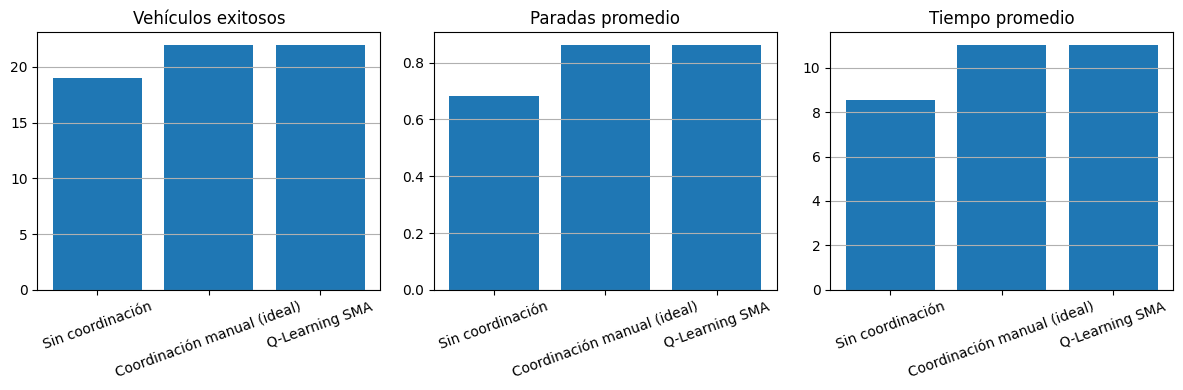

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.bar(df_escenarios["escenario"], df_escenarios["vehiculos_exitosos"])
plt.title("Vehículos exitosos")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.subplot(1,3,2)
plt.bar(df_escenarios["escenario"], df_escenarios["paradas_promedio"])
plt.title("Paradas promedio")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.subplot(1,3,3)
plt.bar(df_escenarios["escenario"], df_escenarios["tiempo_promedio"])
plt.title("Tiempo promedio")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

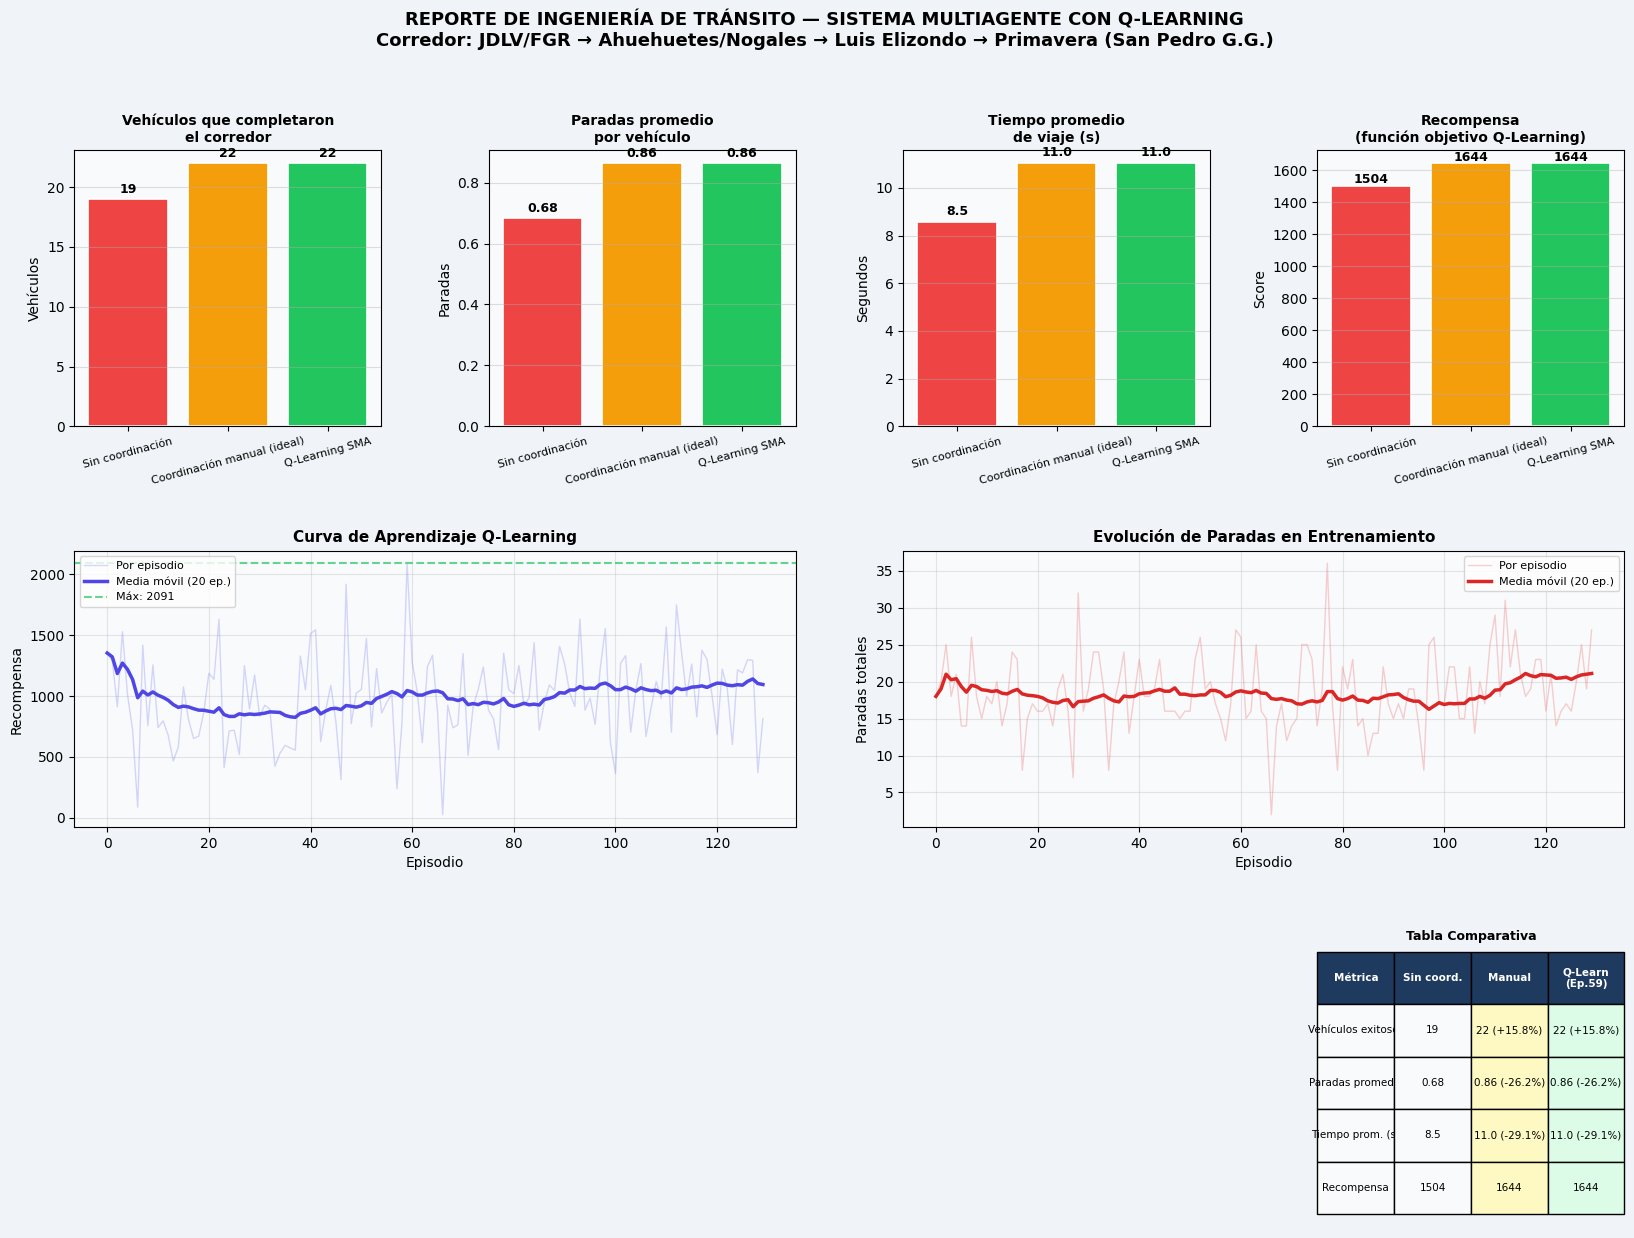


   REPORTE COMPLETO — SISTEMA SMA + Q-LEARNING
   Corredor: Fernando García Roel / Junco de la Vega

DATOS DEL CORREDOR
----------------------------------------
  Cruces monitoreados : 4
    JDLV           → X =    7.4 m
    AHUEHUETES     → X =  167.0 m
    RICARDO        → X =  562.0 m
    PRIMAVERA      → X =  955.1 m

VARIABLES DE INGENIERÍA DE TRÁNSITO
----------------------------------------
  Velocidad de sincronía : 40 km/h  (11.11 m/s)
  Ciclo semafórico base  : 1240 frames = 49.6 s
  Split verde base       : 96 frames = 3.8 s
  Offsets físicos (distancia/velocidad):
    JDLV           →    0.0 m / 11.11 m·s⁻¹ = 0.00 s
    AHUEHUETES     →  159.6 m / 11.11 m·s⁻¹ = 14.36 s
    RICARDO        →  554.6 m / 11.11 m·s⁻¹ = 49.91 s
    PRIMAVERA      →  947.7 m / 11.11 m·s⁻¹ = 85.29 s

PARÁMETROS Q-LEARNING
----------------------------------------
  Episodios entrenados   : 200
  Frames por episodio    : 900 (36 s)
  Espacio de estados     : 3^4 = 81 estados posibles
  Estados visit

In [ ]:

# REPORTE COMPLETO — MÉTRICAS DE INGENIERÍA DE TRÁNSITO
# Integra: SMA, Q-Learning, Comparativa, Onda Verde

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import pandas as pd
# A) FIGURA PRINCIPAL: DASHBOARD DE MÉTRICAS

fig_rep = plt.figure(figsize=(20, 14), facecolor='#f0f4f8')
gs = gridspec.GridSpec(3, 4, figure=fig_rep, hspace=0.45, wspace=0.35)

COLORES_ESC = ['#ef4444', '#f59e0b', '#22c55e']
ESCENARIOS  = [r["escenario"] for r in resultados_escenarios]

# 1. Vehículos exitosos
ax1 = fig_rep.add_subplot(gs[0, 0])
vals = [r["vehiculos_exitosos"] for r in resultados_escenarios]
bars = ax1.bar(ESCENARIOS, vals, color=COLORES_ESC, edgecolor='white', linewidth=1.2)
ax1.set_title("Vehículos que completaron\nel corredor", weight='bold', fontsize=10)
ax1.set_ylabel("Vehículos")
for b, v in zip(bars, vals):
    ax1.text(b.get_x()+b.get_width()/2, v+0.5, str(v), ha='center', fontsize=9, weight='bold')
ax1.set_facecolor('#f8fafc')
ax1.grid(axis='y', alpha=0.4)
plt.setp(ax1.get_xticklabels(), rotation=15, fontsize=8)

# 2. Paradas promedio por vehículo
ax2 = fig_rep.add_subplot(gs[0, 1])
vals2 = [r["paradas_promedio"] for r in resultados_escenarios]
bars2 = ax2.bar(ESCENARIOS, vals2, color=COLORES_ESC, edgecolor='white', linewidth=1.2)
ax2.set_title("Paradas promedio\npor vehículo", weight='bold', fontsize=10)
ax2.set_ylabel("Paradas")
for b, v in zip(bars2, vals2):
    ax2.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha='center', fontsize=9, weight='bold')
ax2.set_facecolor('#f8fafc')
ax2.grid(axis='y', alpha=0.4)
plt.setp(ax2.get_xticklabels(), rotation=15, fontsize=8)

# 3. Tiempo promedio de viaje
ax3 = fig_rep.add_subplot(gs[0, 2])
vals3 = [r["tiempo_promedio"] for r in resultados_escenarios]
bars3 = ax3.bar(ESCENARIOS, vals3, color=COLORES_ESC, edgecolor='white', linewidth=1.2)
ax3.set_title("Tiempo promedio\nde viaje (s)", weight='bold', fontsize=10)
ax3.set_ylabel("Segundos")
for b, v in zip(bars3, vals3):
    ax3.text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.1f}", ha='center', fontsize=9, weight='bold')
ax3.set_facecolor('#f8fafc')
ax3.grid(axis='y', alpha=0.4)
plt.setp(ax3.get_xticklabels(), rotation=15, fontsize=8)

# 4. Recompensa total
ax4 = fig_rep.add_subplot(gs[0, 3])
vals4 = [r["recompensa"] for r in resultados_escenarios]
bars4 = ax4.bar(ESCENARIOS, vals4, color=COLORES_ESC, edgecolor='white', linewidth=1.2)
ax4.set_title("Recompensa\n(función objetivo Q-Learning)", weight='bold', fontsize=10)
ax4.set_ylabel("Score")
for b, v in zip(bars4, vals4):
    ax4.text(b.get_x()+b.get_width()/2, v+(max(vals4)*0.01), f"{v:.0f}", ha='center', fontsize=9, weight='bold')
ax4.set_facecolor('#f8fafc')
ax4.grid(axis='y', alpha=0.4)
plt.setp(ax4.get_xticklabels(), rotation=15, fontsize=8)

# 5. Curva de aprendizaje Q-Learning (reward + smooth)
ax5 = fig_rep.add_subplot(gs[1, :2])
ax5.plot(reward_history, alpha=0.25, color='#6366f1', lw=1, label='Por episodio')
smooth = pd.Series(reward_history).rolling(window=20, min_periods=1).mean()
ax5.plot(smooth, color='#4f46e5', lw=2.5, label='Media móvil (20 ep.)')
ax5.axhline(y=max(reward_history), color='#22c55e', ls='--', alpha=0.7,
            label=f'Máx: {max(reward_history):.0f}')
ax5.set_title("Curva de Aprendizaje Q-Learning", weight='bold', fontsize=11)
ax5.set_xlabel("Episodio")
ax5.set_ylabel("Recompensa")
ax5.legend(fontsize=8)
ax5.set_facecolor('#f8fafc')
ax5.grid(alpha=0.3)

# 6. Evolución de paradas por episodio
ax6 = fig_rep.add_subplot(gs[1, 2:])
ax6.plot(stop_history, alpha=0.25, color='#ef4444', lw=1, label='Por episodio')
smooth_s = pd.Series(stop_history).rolling(window=20, min_periods=1).mean()
ax6.plot(smooth_s, color='#dc2626', lw=2.5, label='Media móvil (20 ep.)')
ax6.set_title("Evolución de Paradas en Entrenamiento", weight='bold', fontsize=11)
ax6.set_xlabel("Episodio")
ax6.set_ylabel("Paradas totales")
ax6.legend(fontsize=8)
ax6.set_facecolor('#f8fafc')
ax6.grid(alpha=0.3)

# 8. Tabla resumen numérica
ax8 = fig_rep.add_subplot(gs[2, 3])
ax8.axis('off')

base_r   = resultados_escenarios[0]
manual_r = resultados_escenarios[1]
ql_r     = resultados_escenarios[2]

def pct(nuevo, base, invert=False):
    if base == 0: return "—"
    v = (nuevo - base) / abs(base) * 100
    if invert: v = -v
    return f"{v:+.1f}%"

tabla_data = [
    ["Métrica",          "Sin coord.", "Manual",
     f"Q-Learn\n(Ep.{best_episode_idx})"],
    ["Vehículos exitosos",
     str(base_r["vehiculos_exitosos"]),
     f"{manual_r['vehiculos_exitosos']} ({pct(manual_r['vehiculos_exitosos'], base_r['vehiculos_exitosos'])})",
     f"{ql_r['vehiculos_exitosos']} ({pct(ql_r['vehiculos_exitosos'], base_r['vehiculos_exitosos'])})"],
    ["Paradas promedio",
     f"{base_r['paradas_promedio']:.2f}",
     f"{manual_r['paradas_promedio']:.2f} ({pct(manual_r['paradas_promedio'], base_r['paradas_promedio'], invert=True)})",
     f"{ql_r['paradas_promedio']:.2f} ({pct(ql_r['paradas_promedio'], base_r['paradas_promedio'], invert=True)})"],
    ["Tiempo prom. (s)",
     f"{base_r['tiempo_promedio']:.1f}",
     f"{manual_r['tiempo_promedio']:.1f} ({pct(manual_r['tiempo_promedio'], base_r['tiempo_promedio'], invert=True)})",
     f"{ql_r['tiempo_promedio']:.1f} ({pct(ql_r['tiempo_promedio'], base_r['tiempo_promedio'], invert=True)})"],
    ["Recompensa",
     f"{base_r['recompensa']:.0f}",
     f"{manual_r['recompensa']:.0f}",
     f"{ql_r['recompensa']:.0f}"],
]

tbl = ax8.table(cellText=tabla_data[1:], colLabels=tabla_data[0],
                cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.95])
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1e3a5f')
        cell.set_text_props(color='white', weight='bold')
    elif c == 3:
        cell.set_facecolor('#dcfce7')
    elif c == 2:
        cell.set_facecolor('#fef9c3')
    else:
        cell.set_facecolor('#f8fafc')

ax8.set_title("Tabla Comparativa", weight='bold', fontsize=9, pad=8)

fig_rep.suptitle(
    "REPORTE DE INGENIERÍA DE TRÁNSITO — SISTEMA MULTIAGENTE CON Q-LEARNING\n"
    "Corredor: JDLV/FGR → Ahuehuetes/Nogales → Luis Elizondo → Primavera (San Pedro G.G.)",
    weight='bold', fontsize=13, y=0.98
)

plt.show()


# B) IMPRESIÓN TEXTUAL COMPLETA

print("\n" + "="*65)
print("   REPORTE COMPLETO — SISTEMA SMA + Q-LEARNING")
print("   Corredor: Fernando García Roel / Junco de la Vega")
print("="*65)

print("\nDATOS DEL CORREDOR")
print("-"*40)
print(f"  Cruces monitoreados : {len(CRUCES_Q)}")
for cruce in CRUCES_Q:
    d = DISTANCIAS_CORREDOR_M[cruce]
    print(f"    {cruce:<14} → X = {d:6.1f} m")

print("\nVARIABLES DE INGENIERÍA DE TRÁNSITO")
print("-"*40)
print(f"  Velocidad de sincronía : {VELOCIDAD_SINCRONIA_MS*3.6:.0f} km/h  ({VELOCIDAD_SINCRONIA_MS:.2f} m/s)")
print(f"  Ciclo semafórico base  : {CICLO_BASE} frames = {CICLO_BASE/FPS:.1f} s")
print(f"  Split verde base       : {CONFIG_SEMAFOROS['JDLV']['duracion_verde']} frames = "
      f"{CONFIG_SEMAFOROS['JDLV']['duracion_verde']/FPS:.1f} s")
print("  Offsets físicos (distancia/velocidad):")
for cruce in CRUCES_Q:
    d = DISTANCIAS_CORREDOR_M[cruce] - DISTANCIAS_CORREDOR_M["JDLV"]
    t = d / VELOCIDAD_SINCRONIA_MS
    print(f"    {cruce:<14} → {d:6.1f} m / {VELOCIDAD_SINCRONIA_MS:.2f} m·s⁻¹ = {t:.2f} s")

print("\nPARÁMETROS Q-LEARNING")
print("-"*40)
print(f"  Episodios entrenados   : {EPISODES}")
print(f"  Frames por episodio    : {FRAMES_ENTRENAMIENTO} ({FRAMES_ENTRENAMIENTO/FPS:.0f} s)")
print(f"  Espacio de estados     : 3^4 = 81 estados posibles")
print(f"  Estados visitados      : {len(Q_TABLE)}")
print(f"  Espacio de acciones    : {N_ACCIONES_QL} (5^3 perturbaciones)")
print(f"  Learning rate (α)      : {alpha}")
print(f"  Factor descuento (γ)   : {gamma}")
print(f"  ε final                : {epsilon:.4f}")

print("\nOFFSETS APRENDIDOS (mejor episodio)")
print("-"*40)
print(f"  Episodio               : {best_episode_idx}")
print(f"  Recompensa máxima      : {best_reward:.1f}")
for cruce, off_f, off_s in zip(CRUCES_Q, best_offsets, best_offsets_sec):
    print(f"    {cruce:<14} → {off_f:4d} frames = {off_s:.2f} s")

print("\nCOMPARATIVA DE ESCENARIOS")
print("-"*65)
print(f"  {'Escenario':<22} {'Exitosos':>10} {'Paradas/veh':>12} {'Tiempo(s)':>10} {'Recompensa':>12}")
print("-"*65)
for r in resultados_escenarios:
    print(f"  {r['escenario']:<22} {r['vehiculos_exitosos']:>10} "
          f"{r['paradas_promedio']:>12.2f} {r['tiempo_promedio']:>10.1f} "
          f"{r['recompensa']:>12.1f}")

print("-"*65)
# Mejoras vs sin coordinación
base_veh = resultados_escenarios[0]['vehiculos_exitosos']
base_par = resultados_escenarios[0]['paradas_promedio']
base_t   = resultados_escenarios[0]['tiempo_promedio']
ql_veh   = resultados_escenarios[2]['vehiculos_exitosos']
ql_par   = resultados_escenarios[2]['paradas_promedio']
ql_t     = resultados_escenarios[2]['tiempo_promedio']

print(f"\n  Mejora Q-Learning vs Sin coordinación:")
if base_veh > 0:
    print(f"    Vehículos exitosos : {(ql_veh-base_veh)/base_veh*100:+.1f}%")
if base_par > 0:
    print(f"    Reducción paradas  : {(base_par-ql_par)/base_par*100:+.1f}%")
if base_t > 0:
    print(f"    Reducción tiempo   : {(base_t-ql_t)/base_t*100:+.1f}%")

print("\n📈 ESTADO DE LA ONDA VERDE")
print("-"*40)
prom_par = resultados_escenarios[2]['paradas_promedio']
if prom_par <= 1.0:
    estado_onda = "✅ EXCELENTE — Onda verde efectiva (< 1 parada/veh)"
elif prom_par <= 2.0:
    estado_onda = "🟡 BUENA — Coordinación parcial (1-2 paradas/veh)"
else:
    estado_onda = "🔴 MEJORABLE — Aumentar episodios o ajustar recompensa"
print(f"  {estado_onda}")

print("\n" + "="*65)
print("  Diagrama guardado en: reporte_metricas.png")
print("="*65)
